# IMDB Text Mining Rough

# 0 Set Up

In [1]:
import pandas as pd
import numpy as np
import kagglehub
import nltk
from nltk import word_tokenize

from collections import Counter

from math import log

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns



## 0.1 Get Data

In [2]:
#download data (commented out once run successfully)

# Download latest version
# path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# print("Path to dataset files:", path)

# Path to dataset files: /Users/wilhelmlannin/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1

In [3]:
# load data
path = "/Users/wilhelmlannin/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1"
df = pd.read_csv(fr"{path}/IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# explore data
print(df.shape)
df['sentiment'].value_counts()

(50000, 2)


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [5]:
# train/test split by randomly selecting 12.5k of the positives and 12.5k of the negatives (i.e. 50% of the data)

train_positive_idx = df[df['sentiment']=='positive'].sample(12500,random_state=42).index
train_negative_idx = df[df['sentiment']=='negative'].sample(12500,random_state=42).index
train_idx = list(train_positive_idx) + list(train_negative_idx)

train_df = df[df.index.isin(train_idx)]
print(train_df.shape)

test_df = df[~df.index.isin(train_idx)]
print(test_df.shape)


(25000, 2)
(25000, 2)


In [6]:
train_df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive


# 1 Explore Data

## 1.1 Readable Print

In [7]:
# function so we can read individual reviews

In [8]:
train_df.iloc[0,0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [9]:
train_df.iloc[0,0][:100]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The"

In [10]:
# function to easily read the review with rowindex=idx by printing line by line
def readable_print(df, idx, linelimit=110):
    # idx is the rowindex we display the review for
    # linelimit = the rough number of characters we display per line

    print('Sentiment:',df.iloc[idx,1])
    print()
    review = df.iloc[idx,0]
    
    current_char = 0
    actual_line_end = linelimit
    # numiter=0
    while current_char <= len(review) and actual_line_end > 0:
        # find which index to go up to by finding the last whitespace BEFORE linelimit many chars
        current_substr = review[current_char:current_char+linelimit]
        # if current_substr is less than linelimit then we just print the remaining characters
        if len(current_substr) < linelimit:
            actual_line_end = linelimit
        else:
            #else, we check for whitespace and split the line at the latest one
            whitespace_list = [char for charid,char in enumerate(current_substr) if char==' ']
            # if no whitespaces, set actual_line_end to be linelimit, else use max whitespace
            if len(whitespace_list) == 0:
                actual_line_end = linelimit
            else:
                actual_line_end = max([charid for charid,char in enumerate(current_substr) if char==' '])
        # print up to actual_line_end
        print(review[current_char:current_char+actual_line_end])
        # print(actual_line_end)
        # print("substr:",current_substr)
        # print('end iter',numiter)
        # print()
        # and update current_char to reflect this
        current_char += actual_line_end
        # numiter+=1
        


In [11]:
readable_print(train_df,30)

Sentiment: negative

What happened? What we have here is basically a solid and plausible premise and with a decent and talented
 cast, but somewhere the movie loses it. Actually, it never really got going. There was a little excitement
 when we find out that Angie is not really pregnant, then find out that she is after all, but that was it.
 Steve Martin, who is a very talented person and usually brings a lot to a movie, was dreadful and his entire
 character was not even close to being important to this movie, other than to make it longer. I really would
 have liked to see more interactions between the main characters, Kate and Angie, and maybe try not for a
 pure comedy, which unfortunately it was not, but maybe a drama with comedic elements. I think if the movie
 did this it could have been very funny since both actresses are quite funny in their own ways and sitting
 here I can think of numerous scenarios that would have been a riot.


In [12]:
train_df.iloc[0,0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

# 2 Intro to NLTK

In [13]:
# downloads:

# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('averaged_perceptron_tagger_eng')

In [14]:
# try tokenizing one review
review0 = train_df.iloc[0,0]
review0
tokenized0 = word_tokenize(review0)
tokenized0
# interesting that "'ll" is one token, from the word you'll


['One',
 'of',
 'the',
 'other',
 'reviewers',
 'has',
 'mentioned',
 'that',
 'after',
 'watching',
 'just',
 '1',
 'Oz',
 'episode',
 'you',
 "'ll",
 'be',
 'hooked',
 '.',
 'They',
 'are',
 'right',
 ',',
 'as',
 'this',
 'is',
 'exactly',
 'what',
 'happened',
 'with',
 'me.',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'The',
 'first',
 'thing',
 'that',
 'struck',
 'me',
 'about',
 'Oz',
 'was',
 'its',
 'brutality',
 'and',
 'unflinching',
 'scenes',
 'of',
 'violence',
 ',',
 'which',
 'set',
 'in',
 'right',
 'from',
 'the',
 'word',
 'GO',
 '.',
 'Trust',
 'me',
 ',',
 'this',
 'is',
 'not',
 'a',
 'show',
 'for',
 'the',
 'faint',
 'hearted',
 'or',
 'timid',
 '.',
 'This',
 'show',
 'pulls',
 'no',
 'punches',
 'with',
 'regards',
 'to',
 'drugs',
 ',',
 'sex',
 'or',
 'violence',
 '.',
 'Its',
 'is',
 'hardcore',
 ',',
 'in',
 'the',
 'classic',
 'use',
 'of',
 'the',
 'word.',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'It',
 'is',
 'called',
 'OZ',
 'as',


In [15]:
# create NLTK Text object from these tokens, so we can use in-built methods
# note that nltk.Text() is for visually exploring the data yourself, not suited for applying to entire dataset
text0 = nltk.Text(tokenized0)
text0


<Text: One of the other reviewers has mentioned that...>

In [16]:
text0.collocations()
# I suppose there are no collocations (2 words that appear unusually often next to each other)

In [17]:
text0.similar("your")
# ?

In [18]:
list(nltk.bigrams(text0))

[('One', 'of'),
 ('of', 'the'),
 ('the', 'other'),
 ('other', 'reviewers'),
 ('reviewers', 'has'),
 ('has', 'mentioned'),
 ('mentioned', 'that'),
 ('that', 'after'),
 ('after', 'watching'),
 ('watching', 'just'),
 ('just', '1'),
 ('1', 'Oz'),
 ('Oz', 'episode'),
 ('episode', 'you'),
 ('you', "'ll"),
 ("'ll", 'be'),
 ('be', 'hooked'),
 ('hooked', '.'),
 ('.', 'They'),
 ('They', 'are'),
 ('are', 'right'),
 ('right', ','),
 (',', 'as'),
 ('as', 'this'),
 ('this', 'is'),
 ('is', 'exactly'),
 ('exactly', 'what'),
 ('what', 'happened'),
 ('happened', 'with'),
 ('with', 'me.'),
 ('me.', '<'),
 ('<', 'br'),
 ('br', '/'),
 ('/', '>'),
 ('>', '<'),
 ('<', 'br'),
 ('br', '/'),
 ('/', '>'),
 ('>', 'The'),
 ('The', 'first'),
 ('first', 'thing'),
 ('thing', 'that'),
 ('that', 'struck'),
 ('struck', 'me'),
 ('me', 'about'),
 ('about', 'Oz'),
 ('Oz', 'was'),
 ('was', 'its'),
 ('its', 'brutality'),
 ('brutality', 'and'),
 ('and', 'unflinching'),
 ('unflinching', 'scenes'),
 ('scenes', 'of'),
 ('of', 'v

In [19]:
nltk.FreqDist(text0)

FreqDist({',': 26, 'the': 14, '.': 10, 'is': 9, 'of': 7, '<': 6, 'br': 6, '/': 6, '>': 6, 'and': 6, ...})

In [20]:
nltk.pos_tag(text0)

[('One', 'CD'),
 ('of', 'IN'),
 ('the', 'DT'),
 ('other', 'JJ'),
 ('reviewers', 'NNS'),
 ('has', 'VBZ'),
 ('mentioned', 'VBN'),
 ('that', 'IN'),
 ('after', 'IN'),
 ('watching', 'VBG'),
 ('just', 'RB'),
 ('1', 'CD'),
 ('Oz', 'NNP'),
 ('episode', 'NN'),
 ('you', 'PRP'),
 ("'ll", 'MD'),
 ('be', 'VB'),
 ('hooked', 'VBN'),
 ('.', '.'),
 ('They', 'PRP'),
 ('are', 'VBP'),
 ('right', 'JJ'),
 (',', ','),
 ('as', 'IN'),
 ('this', 'DT'),
 ('is', 'VBZ'),
 ('exactly', 'RB'),
 ('what', 'WP'),
 ('happened', 'VBD'),
 ('with', 'IN'),
 ('me.', 'JJ'),
 ('<', 'NNP'),
 ('br', 'NN'),
 ('/', 'NNP'),
 ('>', 'NNP'),
 ('<', 'NNP'),
 ('br', 'NN'),
 ('/', 'NNP'),
 ('>', 'VBZ'),
 ('The', 'DT'),
 ('first', 'JJ'),
 ('thing', 'NN'),
 ('that', 'WDT'),
 ('struck', 'VBD'),
 ('me', 'PRP'),
 ('about', 'IN'),
 ('Oz', 'NNP'),
 ('was', 'VBD'),
 ('its', 'PRP$'),
 ('brutality', 'NN'),
 ('and', 'CC'),
 ('unflinching', 'JJ'),
 ('scenes', 'NNS'),
 ('of', 'IN'),
 ('violence', 'NN'),
 (',', ','),
 ('which', 'WDT'),
 ('set', 'VBP'),

In [21]:
# test POS tagger on the word CHAIR used in 2 different meanings (as a noun and a verb)
nltk.pos_tag(word_tokenize("from her chair, she asked Simon 'will you chair this meeting?'"))


[('from', 'IN'),
 ('her', 'PRP$'),
 ('chair', 'NN'),
 (',', ','),
 ('she', 'PRP'),
 ('asked', 'VBD'),
 ('Simon', 'NNP'),
 ("'will", 'NNP'),
 ('you', 'PRP'),
 ('chair', 'VBP'),
 ('this', 'DT'),
 ('meeting', 'NN'),
 ('?', '.'),
 ("'", "''")]

# 3 First Model Attempts

In [22]:
# in this section I want to try fitting models using my limited understanding of NLP so far
# My goals in this section: (1) engineer my own features from the review-string
# (2) write code to train and test several algos: Naive Bayes, Logistic Reg, Light GBM/XGBoost

## 3.1 Flag Most Frequent Tokens

In [23]:
# idea: scan the most common words in the whole set of train reviews, and identify most common words
# we can add features to the model that indicate how often a certain word(s) appear.
# we must filter out all the common words like "the"... perhaps we can use ML to tell us which words to care about.

In [24]:
train_lowtokens = train_df['review'].apply(lambda x: nltk.wordpunct_tokenize(x.lower()))
train_lowtokens.head()


0    [one, of, the, other, reviewers, has, mentione...
3    [basically, there, ', s, a, family, where, a, ...
4    [petter, mattei, ', s, ", love, in, the, time,...
5    [probably, my, all, -, time, favorite, movie, ...
6    [i, sure, would, like, to, see, a, resurrectio...
Name: review, dtype: object

In [25]:
# use counter to count occurrences of each word
Counter(train_lowtokens[0])


Counter({'one': 1,
         'of': 7,
         'the': 16,
         'other': 2,
         'reviewers': 1,
         'has': 1,
         'mentioned': 1,
         'that': 4,
         'after': 1,
         'watching': 2,
         'just': 2,
         '1': 1,
         'oz': 6,
         'episode': 2,
         'you': 3,
         "'": 6,
         'll': 3,
         'be': 2,
         'hooked': 1,
         '.': 10,
         'they': 1,
         'are': 2,
         'right': 2,
         ',': 26,
         'as': 4,
         'this': 3,
         'is': 9,
         'exactly': 1,
         'what': 2,
         'happened': 1,
         'with': 5,
         'me': 4,
         '.<': 3,
         'br': 6,
         '/><': 3,
         '/>': 3,
         'first': 2,
         'thing': 1,
         'struck': 2,
         'about': 1,
         'was': 3,
         'its': 2,
         'brutality': 1,
         'and': 6,
         'unflinching': 1,
         'scenes': 1,
         'violence': 4,
         'which': 1,
         'set': 1,
      

In [26]:
# count how often each (lowercase) token appears across all train cases
all_train_text = ''
for string in train_df['review']:
    all_train_text += string

all_train_lowtokens = nltk.wordpunct_tokenize(all_train_text.lower())
all_train_counter = Counter(all_train_lowtokens)
# print(all_train_counter)


In [27]:
# STEMMING finds the root word in the dictionary for each token (so lying and lies become LIE)
stemmer = nltk.PorterStemmer()
stemmer.stem('lying', to_lowercase=True)


'lie'

In [28]:
# # run the same Counter as we did for all the text above, but this time STEM it!!

# all_train_lowstems = [stemmer.stem(token) for token in all_train_lowtokens]
# all_train_stemcounter = Counter(all_train_lowstems)
# print(all_train_stemcounter)


In [29]:
# print(all_train_stemcounter)
# # some of the outputs do not look like full words e.g. 'movi': 51681 (why has stemmer done this?)


In [30]:
# stemmer.stem('movie')
# # that seems wrong, I'll leave the stemmer for now


In [31]:
# # can we filter out the most obvious/common words in th english language from all_train_counter?
# # for now I will go through and list some of the most common ones that I don't want to include:
# print(all_train_counter)

In [32]:
token_df = pd.DataFrame({'tokens':[key for key,val in all_train_counter.items()]
                  ,'num_occurences':[val for key,val in all_train_counter.items()]
}).sort_values(by='num_occurences',ascending=False)


In [33]:
token_df.iloc[0:60]

,tokens,num_occurences
2,the,334463
23,",",260505
19,.,230073
43,and,162698
55,a,161735
1,of,144953
66,to,134223
15,',128548
26,is,105589
33,br,100521


In [34]:
ignore_tokens = ['the',',','.','and','a','of','to',";",'is','it','in','i','this','that','s',
                 '-', '/><', '"', '/>', 'was','as','for', "'", 'br',
                 # up to here I included all the first n in the Counter... now I'm being picky
                 '.<','on','t','(','are','have','be','all','at','by','an','so','there',')']
# 'br' was one... what is that? I left it in.

In [35]:
# we should now create features from the most recurring words NOT in ignore_tokens
unignore_train_counter = Counter({key:val for key,val in all_train_counter.items() if key not in ignore_tokens})
# print(unignore_train_counter)

In [36]:
# how many distinct tokens have we got now?
len(unignore_train_counter.keys())
# 79552 ! 

79552

In [37]:
# check how many tokens appear in less than 1250 of the reviews (that would be 5%)
less_than_1250_count = len([key for key,val in unignore_train_counter.items() if val<1250])

print('if we remove tokens that appear in less than 1250 reviews (< 5%), we would be left with:')
print(len(unignore_train_counter.keys()) - less_than_1250_count, 'tokens')

if we remove tokens that appear in less than 1250 reviews (< 5%), we would be left with:
483 tokens


In [38]:
# filter the dictionary down to only the tokens selected in the last cell
tokens_v1 = [key for key,val in unignore_train_counter.items() if val>=1250]
print(tokens_v1)


['one', 'other', 'has', 'after', 'watching', 'just', '1', 'episode', 'you', 'll', 'they', 'right', 'what', 'with', 'me', 'first', 'thing', 'about', 'its', 'scenes', 'which', 'set', 'from', 'go', 'not', 'show', 'or', 'no', 'sex', 'classic', 'use', 'called', 'given', 'where', 'face', 'high', 'home', 'many', '..', 'more', 'death', 'never', 'far', 'away', 'would', 'say', 'main', 'fact', 'goes', 'shows', 'pretty', '...', 'doesn', 'around', 'ever', 'saw', 'couldn', 'but', 'watched', 'got', 'who', 'out', 'get', 'well', 'being', 'into', 'their', 'may', 'become', 'if', 'can', 'your', 'side', 'family', 'little', 'boy', 'his', '&', 'time', 'movie', 'than', 'when', 're', 'going', 'make', 'film', 'must', 'drama', '!', 'like', 'real', 'life', 'then', 'we', 'totally', 'see', 'instead', 'some', '3', '10', 'playing', ':', 'them', 'love', 'money', 'watch', 'mr', 'us', 'human', 'seems', 'do', 'people', 'different', '<', 'play', 'same', 'director', 'action', 'new', 'these', 'characters', 'each', 'way', 'a

In [39]:
# create features that tell you if that token appeared in each review

#column containing lowcase tokenised review
train_df['tokenised'] = train_df['review'].apply(lambda x: nltk.wordpunct_tokenize(x.lower()))

for token in tokens_v1:
    train_df[f'ind_{token}'] = train_df['tokenised'].apply(lambda x: token in x)


    


/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_4324/2155259994.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['tokenised'] = train_df['review'].apply(lambda x: nltk.wordpunct_tokenize(x.lower()))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_4324/2155259994.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[f'ind_{token}'] = train_df['tokenised'].apply(lambda x: token in x)
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_4324/2155259994.py:7: Setti

In [40]:
train_df.head(2)

,review,sentiment,tokenised,ind_one,ind_other,ind_has,ind_after,ind_watching,ind_just,ind_1,...,ind_said,ind_short,ind_history,ind_heart,ind_dead,ind_mind,ind_poor,ind_understand,ind_,ind_already
0,One of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione...",True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
3,Basically there's a family where a little boy ...,negative,"[basically, there, ', s, a, family, where, a, ...",False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
# now try these features in a logistic regression to see which are most predictive
# could calculate weights of evidence and information value!
# -0.3065*(0.184-0.25)
# we need to calculate %positive-sentiment/%negative-sentiment for both True and False for each column



In [42]:
# define target column
train_df['target'] = np.where(train_df['sentiment']=='positive',1,0)
train_df['target'].value_counts()


/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_4324/1356803125.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['target'] = np.where(train_df['sentiment']=='positive',1,0)
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_4324/1356803125.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['target'] = np.where(train_df['sentiment']=='positive',1,0)


target
1    12500
0    12500
Name: count, dtype: int64

In [43]:
def binary_woe(df,binary_col_to_woe,binary_target_col,eps=0.0000001):
    # this function replaces the column binary_col_to_woe in df with a WOE encoding.
    # it also calculates IV and returns that

    #df = dataframe with columns col_to_woe and binary_target_col
    # binary_col_to_woe is the column name for a binary column you want to do WOE to
    # binary_target_col is the column name for the binary target for your logistic regression
    # eps = small number used to handle rare cases where

    df = df.copy()
    
    rates_df = df[[binary_col_to_woe,binary_target_col]].groupby(binary_col_to_woe)[binary_target_col].value_counts(normalize=True)
    woe_mapping={}
    
    iv = 0
    for val in [True,False]:
        event_rate = rates_df.loc[rates_df.index==(val,1)].min()
        nonevent_rate = rates_df.loc[rates_df.index==(val,0)].min()
        # weight of evidence calculation, rounded to 4 dp
        woe = round(log(event_rate/(nonevent_rate+eps)),4)
        woe_mapping[val] = woe
        iv += woe*(event_rate-nonevent_rate)
    
    # replace column in df
    df[binary_col_to_woe] = df[binary_col_to_woe].apply(lambda x: woe_mapping[x])

    return df, iv, woe_mapping
    

mydf,iv,woe_mapping = binary_woe(train_df,'ind_watching','target')
print('information value =',iv)
mydf['ind_watching'].head()


information value = 0.05699224432585976


0   -0.3338
3    0.0599
4    0.0599
5    0.0599
6    0.0599
Name: ind_watching, dtype: float64

In [44]:
# now run this for all columns, creating a new dataframe and storing the IV
iv_df = pd.DataFrame(columns=['col','iv'])

woe_train_df = train_df.copy()

woe_mappings = {}
idx=0
for token in tokens_v1:
    col = f'ind_{token}'
    woe_train_df,iv,woe_mapping = binary_woe(woe_train_df,col,'target')
    # add iv to iv_df
    iv_df = pd.concat([iv_df,pd.DataFrame({'col':[col],'iv':[iv]},index=[idx])])
    idx+=1
    #finally, store the woe_mapping
    woe_mappings[token] = woe_mapping


In [45]:
iv_df_sorted = iv_df.sort_values(by='iv',ascending=False)
iv_df_sorted['rounded_iv'] = iv_df_sorted['iv'].apply(lambda x: float(round(x,6)))
iv_df_sorted
# there are some suspiciously predictive words such as WASTE with IV over 2!

,col,iv,rounded_iv
299,ind_waste,2.138138e+00,2.138138
386,ind_worst,1.846896e+00,1.846896
293,ind_awful,1.771836e+00,1.771836
348,ind_terrible,1.216446e+00,1.216446
443,ind_stupid,1.142711e+00,1.142711
...,...,...,...
99,ind_10,2.922636e-06,0.000003
374,ind_almost,1.141509e-06,0.000001
288,ind_version,1.009261e-06,0.000001
209,ind_itself,9.717647e-07,0.000001


In [46]:
# IV interpretation I found online:
# Information Value:	Predictive power
# <0.02:	Useless
# 0.02 to 0.1:	Weak predictors
# 0.1 to 0.3:	Medium Predictors
# 0.3 to 0.5:	Strong predictors
# >0.5:	Suspicious

In [47]:
iv_df_sorted.head(30)

,col,iv,rounded_iv
299,ind_waste,2.138138,2.138138
386,ind_worst,1.846896,1.846896
293,ind_awful,1.771836,1.771836
348,ind_terrible,1.216446,1.216446
443,ind_stupid,1.142711,1.142711
342,ind_worse,1.051003,1.051003
339,ind_wonderful,0.874437,0.874437
154,ind_boring,0.859258,0.859258
284,ind_excellent,0.828348,0.828348
479,ind_poor,0.785042,0.785042


In [48]:
# check how many have at least 0.1 IV:
print(sum(iv_df_sorted['iv']>=0.1), 'have 0.1 IV or higher')

print(sum(iv_df_sorted['iv']>=0.3), 'have 0.3 IV or higher')


85 have 0.1 IV or higher
23 have 0.3 IV or higher


In [49]:
iv_df_sorted[iv_df_sorted['iv']>=0.3].col.tolist()

['ind_waste',
 'ind_worst',
 'ind_awful',
 'ind_terrible',
 'ind_stupid',
 'ind_worse',
 'ind_wonderful',
 'ind_boring',
 'ind_excellent',
 'ind_poor',
 'ind_supposed',
 'ind_perfect',
 'ind_amazing',
 'ind_loved',
 'ind_bad',
 'ind_oh',
 'ind_minutes',
 'ind_beautiful',
 'ind_4',
 'ind_enjoyed',
 'ind_1',
 'ind_money',
 'ind_guess']

In [50]:
# create a dictionary of possible sets of features, so we can easily interchange later
featlists_dict = {'WOE (IV>=0.3)': iv_df_sorted[iv_df_sorted['iv']>=0.3].col.tolist(),
                  'WOE (IV>=0.1)': iv_df_sorted[iv_df_sorted['iv']>=0.1].col.tolist()}
print(featlists_dict)

{'WOE (IV>=0.3)': ['ind_waste', 'ind_worst', 'ind_awful', 'ind_terrible', 'ind_stupid', 'ind_worse', 'ind_wonderful', 'ind_boring', 'ind_excellent', 'ind_poor', 'ind_supposed', 'ind_perfect', 'ind_amazing', 'ind_loved', 'ind_bad', 'ind_oh', 'ind_minutes', 'ind_beautiful', 'ind_4', 'ind_enjoyed', 'ind_1', 'ind_money', 'ind_guess'], 'WOE (IV>=0.1)': ['ind_waste', 'ind_worst', 'ind_awful', 'ind_terrible', 'ind_stupid', 'ind_worse', 'ind_wonderful', 'ind_boring', 'ind_excellent', 'ind_poor', 'ind_supposed', 'ind_perfect', 'ind_amazing', 'ind_loved', 'ind_bad', 'ind_oh', 'ind_minutes', 'ind_beautiful', 'ind_4', 'ind_enjoyed', 'ind_1', 'ind_money', 'ind_guess', 'ind_couldn', 'ind_*', 'ind_great', 'ind_nothing', 'ind_3', 'ind_heart', 'ind_unfortunately', 'ind_performances', 'ind_script', 'ind_instead', 'ind_lives', 'ind_2', 'ind_classic', 'ind_?', 'ind_reason', 'ind_mean', 'ind_war', 'ind_low', 'ind_performance', 'ind_best', 'ind_looks', 'ind_half', 'ind_dialogue', 'ind_definitely', 'ind_give

In [51]:
# first, prepare the test dataset with the same WOE encoding as train



# define target column
test_df['target'] = np.where(test_df['sentiment']=='positive',1,0)
test_df['target'].value_counts()

# create features that tell you if that token appeared in each review

#column containing lowcase tokenised review
test_df['tokenised'] = test_df['review'].apply(lambda x: nltk.wordpunct_tokenize(x.lower()))

woe_test_df = test_df.copy()
for token in tokens_v1:
    woe_map = woe_mappings[token]
    woe_test_df[f'ind_{token}'] = woe_test_df['tokenised'].apply(lambda x: token in x)
    test_df[f'ind_{token}'] = woe_test_df[f'ind_{token}']
    for val in [True,False]:
        #map to WOE
        woe_test_df.loc[woe_test_df[f'ind_{token}']==val, f'ind_{token}'] = woe_map[val]



/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/3908636488.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['target'] = np.where(test_df['sentiment']=='positive',1,0)
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/3908636488.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['tokenised'] = test_df['review'].apply(lambda x: nltk.wordpunct_tokenize(x.lower()))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/3908636488.py:18: SettingWithCopy

In [52]:
woe_test_df.head(3)

,review,sentiment,target,tokenised,ind_one,ind_other,ind_has,ind_after,ind_watching,ind_just,...,ind_said,ind_short,ind_history,ind_heart,ind_dead,ind_mind,ind_poor,ind_understand,ind_,ind_already
1,A wonderful little production. <br /><br />The...,positive,1,"[a, wonderful, little, production, ., <, br, /...",0.0205,-0.0294,0.1141,0.0086,-0.3338,0.1947,...,0.0169,-0.0067,-0.0192,-0.0323,0.0151,-0.004,0.0803,0.0014,0.0011,0.0105
2,I thought this was a wonderful way to spend ti...,positive,1,"[i, thought, this, was, a, wonderful, way, to,...",0.0205,-0.0294,-0.0756,0.0086,-0.3338,0.1947,...,0.0169,-0.0067,-0.0192,-0.0323,0.0151,-0.004,0.0803,0.0014,0.0011,0.0105
7,"This show was an amazing, fresh & innovative i...",negative,0,"[this, show, was, an, amazing, ,, fresh, &, in...",0.0205,-0.0294,0.1141,-0.0289,0.0599,-0.2683,...,0.0169,-0.0067,-0.0192,-0.0323,0.0151,-0.004,0.0803,0.0014,0.0011,0.0105


### 3.1.1 Logistic Regression

In [53]:
# write a function where we pass train, test dataframes and list of features and it does all

def logreg_fit_and_summary(training_data,test_data,features,use_scaling=False,return_sig_vars=False,print_all=True):

    training_data=training_data.copy()
    test_data=test_data.copy()

    # Prepare the training data
    X_train = training_data[features]
    y_train = training_data['target']

    # Prepare the test data
    X_test = test_data[features]
    y_test = test_data['target']

    if use_scaling:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_train = X_train_scaled
        X_test_scaled = scaler.transform(X_test)
        X_test = X_test_scaled

    # Initialize and train the logistic regression model on the entire training dataset
    log_reg = LogisticRegression(
        random_state=42,
        max_iter=1000,  # Increase if convergence issues
        solver='lbfgs'  # Better for medium-large datasets like yours (25k samples)
    )

    # Fit the model on the entire training dataset
    log_reg.fit(X_train, y_train)

    # Make predictions on training data (for comparison)
    y_train_pred = log_reg.predict(X_train)
    y_train_pred_proba = log_reg.predict_proba(X_train)[:, 1]

    # Make predictions on test data
    y_test_pred = log_reg.predict(X_test)
    y_test_pred_proba = log_reg.predict_proba(X_test)[:, 1]

    # Calculate performance metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    test_auc = roc_auc_score(y_test, y_test_pred_proba)

    # Feature importance (coefficients)
    feature_importance = pd.DataFrame({
        'feature': features,
        'coefficient': log_reg.coef_[0],
        'abs_coefficient': np.abs(log_reg.coef_[0])
    }).sort_values('abs_coefficient', ascending=False)

    # Store test predictions in the test dataframe for further analysis
    test_data['predicted_class'] = y_test_pred
    test_data['predicted_probability'] = y_test_pred_proba

    # Generate statistical summary
    def get_logistic_regression_summary(model, feature_names, X_train, y_train):
        """
        Create a statistical summary similar to statsmodels output
        """
        import scipy.stats as stats
        
        # Get model parameters
        coef = model.coef_[0]
        intercept = model.intercept_[0]
        
        # Calculate standard errors using the inverse of Fisher Information Matrix
        # For logistic regression: Fisher Info = X.T @ W @ X where W is diagonal weight matrix
        X_with_intercept = np.column_stack([np.ones(X_train.shape[0]), X_train])
        
        # Get predicted probabilities
        pred_proba = model.predict_proba(X_train)[:, 1]
        
        # Weight matrix (diagonal)
        W = np.diag(pred_proba * (1 - pred_proba))
        
        # Fisher Information Matrix
        fisher_info = X_with_intercept.T @ W @ X_with_intercept
        
        # Covariance matrix (inverse of Fisher Information)
        try:
            cov_matrix = np.linalg.inv(fisher_info)
            std_errors = np.sqrt(np.diag(cov_matrix))
        except np.linalg.LinAlgError:
            # If matrix is singular, use pseudo-inverse
            cov_matrix = np.linalg.pinv(fisher_info)
            std_errors = np.sqrt(np.diag(cov_matrix))
        
        # Combine intercept and coefficients
        all_coefs = np.concatenate([[intercept], coef])
        all_names = ['Intercept'] + feature_names
        
        # Calculate z-scores and p-values
        z_scores = all_coefs / std_errors
        p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))
        
        # Calculate confidence intervals (95%)
        ci_lower = all_coefs - 1.96 * std_errors
        ci_upper = all_coefs + 1.96 * std_errors
        
        # Calculate odds ratios
        odds_ratios = np.exp(all_coefs)
        or_ci_lower = np.exp(ci_lower)
        or_ci_upper = np.exp(ci_upper)
        
        # Create summary dataframe
        summary_df = pd.DataFrame({
            'Variable': all_names,
            'Coefficient': all_coefs,
            'Std_Error': std_errors,
            'Z_Score': z_scores,
            'P_Value': p_values,
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            'Odds_Ratio': odds_ratios,
            'OR_CI_Lower': or_ci_lower,
            'OR_CI_Upper': or_ci_upper
        })
        
        # Add significance stars
        def get_significance_stars(p_val):
            if p_val < 0.001:
                return '***'
            elif p_val < 0.01:
                return '**'
            elif p_val < 0.05:
                return '*'
            elif p_val < 0.1:
                return '.'
            else:
                return ''
        
        summary_df['Significance'] = summary_df['P_Value'].apply(get_significance_stars)
        
        return summary_df

    # Get the summary
    summary_stats = get_logistic_regression_summary(
        log_reg, features, X_train, y_train
    )

    # Count significant variables
    sig_vars = summary_stats[summary_stats['P_Value'] < 0.05]

    # All print statements grouped at the end within if print_all block
    if print_all:
        print("=== Model Performance Results ===")
        print(f"Training Accuracy: {train_accuracy:.4f}")
        print(f"Test Accuracy: {test_accuracy:.4f}")
        print(f"Training AUC: {train_auc:.4f}")
        print(f"Test AUC: {test_auc:.4f}")

        print(f"\nDataset sizes:")
        print(f"Training set: {len(training_data)} samples")
        print(f"Test set: {len(test_data)} samples")

        print("\n=== Test Set Classification Report ===")
        print(classification_report(y_test, y_test_pred))

        print("\n=== Test Set Confusion Matrix ===")
        print(confusion_matrix(y_test, y_test_pred))

        print("\n=== Feature Importance (Top 10) ===")
        print(feature_importance.head(10))

        print("\n=== Performance Summary ===")
        print(f"Model trained on {len(training_data)} samples with {len(features)} features")
        print(f"Test performance: AUC = {test_auc:.4f}, Accuracy = {test_accuracy:.4f}")

        print("LOGISTIC REGRESSION STATISTICAL SUMMARY")
        print("="*80)

        print(f"\nModel: Logistic Regression")
        print(f"Number of observations: {len(y_train)}")
        print(f"Number of features: {len(features)}")

        print(f"\nCoefficients and Statistical Tests:")
        print("-" * 120)
        print(f"{'Variable':<20} {'Coef':<10} {'Std Err':<10} {'z':<8} {'P>|z|':<10} {'[0.025':<10} {'0.975]':<10} {'Odds Ratio':<12} {'OR 95% CI':<20} {'Sig':<5}")
        print("-" * 120)

        for _, row in summary_stats.iterrows():
            or_ci = f"({row['OR_CI_Lower']:.3f}, {row['OR_CI_Upper']:.3f})"
            print(f"{row['Variable']:<20} {row['Coefficient']:<10.4f} {row['Std_Error']:<10.4f} "
                f"{row['Z_Score']:<8.3f} {row['P_Value']:<10.4f} {row['CI_Lower']:<10.4f} "
                f"{row['CI_Upper']:<10.4f} {row['Odds_Ratio']:<12.4f} {or_ci:<20} {row['Significance']:<5}")

        print("\nSignif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")

        print(f"\nNumber of statistically significant variables (p < 0.05): {len(sig_vars) - 1}")  # -1 for intercept

        print("\n" + "="*80)
    
    if return_sig_vars:
        return sig_vars
    
    return summary_stats
    
    

In [54]:
featlist = featlists_dict['WOE (IV>=0.3)']
logreg_fit_and_summary(training_data=woe_train_df,test_data=woe_test_df,features=featlist,use_scaling=True)


=== Model Performance Results ===
Training Accuracy: 0.7574
Test Accuracy: 0.7544
Training AUC: 0.8287
Test AUC: 0.8284

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.78      0.71      0.74     12500
           1       0.73      0.80      0.77     12500

    accuracy                           0.75     25000
   macro avg       0.76      0.75      0.75     25000
weighted avg       0.76      0.75      0.75     25000


=== Test Set Confusion Matrix ===
[[ 8851  3649]
 [ 2490 10010]]

=== Feature Importance (Top 10) ===
          feature  coefficient  abs_coefficient
1       ind_worst     0.538745         0.538745
0       ind_waste     0.483469         0.483469
14        ind_bad     0.432921         0.432921
2       ind_awful     0.414746         0.414746
8   ind_excellent     0.358021         0.358021
7      ind_boring     0.318449         0.318449
4     

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance
0,Intercept,-0.179756,0.017487,-10.279658,0.000000e+00,-0.214030,-0.145482,0.835474,0.807324,0.864605,***
1,ind_waste,0.483469,0.025959,18.624256,0.000000e+00,0.432589,0.534349,1.621690,1.541243,1.706337,***
2,ind_worst,0.538745,0.023103,23.318840,0.000000e+00,0.493463,0.584028,1.713855,1.637978,1.793247,***
3,ind_awful,0.414746,0.023148,17.917102,0.000000e+00,0.369376,0.460116,1.513986,1.446831,1.584258,***
4,ind_terrible,0.296178,0.020630,14.356398,0.000000e+00,0.255742,0.336613,1.344709,1.291420,1.400197,***
5,ind_stupid,0.299084,0.019865,15.055756,0.000000e+00,0.260149,0.338020,1.348623,1.297123,1.402168,***
6,ind_worse,0.242204,0.019498,12.422089,0.000000e+00,0.203988,0.280420,1.274054,1.226284,1.323685,***
7,ind_wonderful,0.276688,0.018619,14.860153,0.000000e+00,0.240194,0.313182,1.318755,1.271495,1.367770,***
8,ind_boring,0.318449,0.018217,17.480928,0.000000e+00,0.282744,0.354154,1.374993,1.326765,1.424975,***
9,ind_excellent,0.358021,0.018454,19.400913,0.000000e+00,0.321852,0.394191,1.430496,1.379680,1.483184,***


In [55]:
# model does perform even better with all 80+ of the vars with IV>=0.1
featlist = featlists_dict['WOE (IV>=0.1)']
logreg_fit_and_summary(training_data=woe_train_df,test_data=woe_test_df,features=featlist,use_scaling=True)


=== Model Performance Results ===
Training Accuracy: 0.8060
Test Accuracy: 0.8033
Training AUC: 0.8843
Test AUC: 0.8859

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.79      0.80     12500
           1       0.79      0.82      0.81     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000


=== Test Set Confusion Matrix ===
[[ 9818  2682]
 [ 2236 10264]]

=== Feature Importance (Top 10) ===
          feature  coefficient  abs_coefficient
1       ind_worst     0.503746         0.503746
0       ind_waste     0.442587         0.442587
25      ind_great     0.395477         0.395477
2       ind_awful     0.384963         0.384963
14        ind_bad     0.363924         0.363924
8   ind_excellent     0.320215         0.320215
9     

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance
0,Intercept,-0.173288,0.019128,-9.059302,0.000000e+00,-0.210779,-0.135797,0.840896,0.809953,0.873020,***
1,ind_waste,0.442587,0.028490,15.534786,0.000000e+00,0.386747,0.498428,1.556730,1.472184,1.646131,***
2,ind_worst,0.503746,0.024992,20.156051,0.000000e+00,0.454761,0.552730,1.654908,1.575796,1.737992,***
3,ind_awful,0.384963,0.025083,15.347813,0.000000e+00,0.335801,0.434125,1.469560,1.399061,1.543612,***
4,ind_terrible,0.279471,0.023042,12.128900,0.000000e+00,0.234310,0.324633,1.322431,1.264036,1.383523,***
...,...,...,...,...,...,...,...,...,...,...,...
81,ind_horror,0.029795,0.018243,1.633177,1.024318e-01,-0.005962,0.065552,1.030243,0.994055,1.067748,
82,ind_didn,0.055251,0.018194,3.036747,2.391462e-03,0.019590,0.090911,1.056805,1.019783,1.095171,**
83,ind_mother,0.040218,0.018156,2.215178,2.674784e-02,0.004633,0.075804,1.041038,1.004644,1.078751,*
84,ind_shows,0.114372,0.017629,6.487581,8.722556e-11,0.079818,0.148925,1.121169,1.083090,1.160586,***


### 3.1.2 Naive Bayes Classifier

In [56]:
def nbayes_fit_and_summary(training_data,test_data,features):

    training_data=training_data.copy()
    test_data=test_data.copy()

    # Assuming you have woe_train_df, woe_test_df and features defined
    # woe_train_df = your training dataframe
    # woe_test_df = your test dataframe
    # features = your list of feature columns

    # Prepare the training data
    X_train = woe_train_df[features]
    y_train = woe_train_df['target']

    # Prepare the test data
    X_test = woe_test_df[features]
    y_test = woe_test_df['target']

    # Initialize and train the Gaussian Naive Bayes classifier
    nb_classifier = GaussianNB()

    # Fit the model on the entire training dataset
    nb_classifier.fit(X_train, y_train)

    # Make predictions on training data (for comparison)
    y_train_pred = nb_classifier.predict(X_train)
    y_train_pred_proba = nb_classifier.predict_proba(X_train)[:, 1]

    # Make predictions on test data
    y_test_pred = nb_classifier.predict(X_test)
    y_test_pred_proba = nb_classifier.predict_proba(X_test)[:, 1]

    # Calculate performance metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    test_auc = roc_auc_score(y_test, y_test_pred_proba)

    # Print results
    print("=== Naive Bayes Model Performance Results ===")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Training AUC: {train_auc:.4f}")
    print(f"Test AUC: {test_auc:.4f}")

    print(f"\nDataset sizes:")
    print(f"Training set: {len(woe_train_df)} samples")
    print(f"Test set: {len(woe_test_df)} samples")

    print("\n=== Test Set Classification Report ===")
    print(classification_report(y_test, y_test_pred))

    print("\n=== Test Set Confusion Matrix ===")
    print(confusion_matrix(y_test, y_test_pred))

    # Naive Bayes specific analysis
    def analyze_naive_bayes_parameters(model, feature_names):
        """
        Analyze the learned parameters of the Gaussian Naive Bayes model
        """
        print("\n" + "="*80)
        print("NAIVE BAYES MODEL ANALYSIS")
        print("="*80)
        
        n_classes = len(model.classes_)
        n_features = len(feature_names)
        
        print(f"\nModel Parameters:")
        print(f"Number of classes: {n_classes}")
        print(f"Number of features: {n_features}")
        print(f"Classes: {model.classes_}")
        
        # Class priors
        print(f"\nClass Priors:")
        for i, class_label in enumerate(model.classes_):
            print(f"  Class {class_label}: {model.class_prior_[i]:.4f}")
        
        # Feature statistics by class
        print(f"\nFeature Statistics by Class:")
        print("-" * 100)
        print(f"{'Feature':<25} {'Class 0 Mean':<15} {'Class 0 Var':<15} {'Class 1 Mean':<15} {'Class 1 Var':<15}")
        print("-" * 100)
        
        feature_analysis = []
        for i, feature in enumerate(feature_names):
            class_0_mean = model.theta_[0, i]
            class_0_var = model.var_[0, i]
            class_1_mean = model.theta_[1, i] if n_classes > 1 else 0
            class_1_var = model.var_[1, i] if n_classes > 1 else 0
            
            print(f"{feature:<25} {class_0_mean:<15.4f} {class_0_var:<15.4f} "
                f"{class_1_mean:<15.4f} {class_1_var:<15.4f}")
            
            # Calculate feature importance as difference in means weighted by variance
            if n_classes > 1:
                mean_diff = abs(class_1_mean - class_0_mean)
                avg_var = (class_0_var + class_1_var) / 2
                importance = mean_diff / (np.sqrt(avg_var) + 1e-10)  # Add small constant to avoid division by zero
                
                feature_analysis.append({
                    'feature': feature,
                    'mean_difference': mean_diff,
                    'importance_score': importance,
                    'class_0_mean': class_0_mean,
                    'class_1_mean': class_1_mean
                })
        
        # Feature importance ranking
        if feature_analysis:
            feature_importance_df = pd.DataFrame(feature_analysis)
            feature_importance_df = feature_importance_df.sort_values('importance_score', ascending=False)
            
            print(f"\n=== Feature Importance Ranking (Top 15) ===")
            print("Based on standardized mean difference between classes")
            print("-" * 80)
            print(f"{'Rank':<6} {'Feature':<25} {'Importance':<12} {'Mean Diff':<12} {'Class 0':<10} {'Class 1':<10}")
            print("-" * 80)
            
            for idx, row in feature_importance_df.head(15).iterrows():
                rank = feature_importance_df.index.get_loc(idx) + 1
                print(f"{rank:<6} {row['feature']:<25} {row['importance_score']:<12.4f} "
                    f"{row['mean_difference']:<12.4f} {row['class_0_mean']:<10.4f} {row['class_1_mean']:<10.4f}")
            
            return feature_importance_df
        
        return None

    # Run Naive Bayes analysis
    analyze_naive_bayes_parameters(nb_classifier, features)


In [57]:
featlist = featlists_dict['WOE (IV>=0.3)']
nbayes_fit_and_summary(training_data=woe_train_df,test_data=woe_test_df,features=featlist)
# slightly worse performance than the logistic regression

=== Naive Bayes Model Performance Results ===
Training Accuracy: 0.7410
Test Accuracy: 0.7402
Training AUC: 0.8216
Test AUC: 0.8220

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.65      0.71     12500
           1       0.70      0.83      0.76     12500

    accuracy                           0.74     25000
   macro avg       0.75      0.74      0.74     25000
weighted avg       0.75      0.74      0.74     25000


=== Test Set Confusion Matrix ===
[[ 8071  4429]
 [ 2065 10435]]

NAIVE BAYES MODEL ANALYSIS

Model Parameters:
Number of classes: 2
Number of features: 23
Classes: [0 1]

Class Priors:
  Class 0: 0.5000
  Class 1: 0.5000

Feature Statistics by Class:
----------------------------------------------------------------------------------------------------
Feature                   Class 0 Mean    Class 0 Var     Class 1 Mean    Class

In [58]:
featlist = featlists_dict['WOE (IV>=0.1)']
nbayes_fit_and_summary(training_data=woe_train_df,test_data=woe_test_df,features=featlist)
# slightly worse performance than the logistic regression

=== Naive Bayes Model Performance Results ===
Training Accuracy: 0.7796
Test Accuracy: 0.7752
Training AUC: 0.8618
Test AUC: 0.8620

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.73      0.76     12500
           1       0.75      0.82      0.79     12500

    accuracy                           0.78     25000
   macro avg       0.78      0.78      0.77     25000
weighted avg       0.78      0.78      0.77     25000


=== Test Set Confusion Matrix ===
[[ 9112  3388]
 [ 2232 10268]]

NAIVE BAYES MODEL ANALYSIS

Model Parameters:
Number of classes: 2
Number of features: 85
Classes: [0 1]

Class Priors:
  Class 0: 0.5000
  Class 1: 0.5000

Feature Statistics by Class:
----------------------------------------------------------------------------------------------------
Feature                   Class 0 Mean    Class 0 Var     Class 1 Mean    Class

In [59]:
# current champion model is logistic regression with featlists_dict['WOE (IV>=0.1)'] features
#  === Model Performance Results ===
# Training Accuracy: 0.8060
# Test Accuracy: 0.8030
# Training AUC: 0.8843
# Test AUC: 0.8859

### 3.1.3 Gradient Boosted Decision Trees

In [60]:
import catboost as cb 

cbm = cb.CatBoostClassifier(random_seed=42,verbose=0)

features = featlists_dict['WOE (IV>=0.3)']
X_train = woe_train_df[features]
y_train = woe_train_df['target']

X_test = woe_test_df[features]
y_test = woe_test_df['target']

cbm_fitted = cbm.fit(X_train,y_train)

y_train_proba2 = cbm.predict_proba(X_train)
y_train_proba = [y_train_proba2[i][1] for i,x in enumerate(y_train_proba2)]
y_train_pred = [p>0.5 for p in y_train_proba]
y_test_proba2 = cbm.predict_proba(X_test)
y_test_proba = [y_test_proba2[i][1] for i,x in enumerate(y_test_proba2)]
y_test_pred = [p>0.5 for p in y_test_proba]

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

print("=== Model Performance Results ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Training AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

print(f"\nPerformance Summary:")
print(f"Accuracy improvement (test vs train): {test_accuracy - train_accuracy:+.4f}")
print(f"AUC improvement (test vs train): {test_auc - train_auc:+.4f}")



=== Model Performance Results ===
Training Accuracy: 0.7695
Test Accuracy: 0.7526
Training AUC: 0.7695
Test AUC: 0.7526

Performance Summary:
Accuracy improvement (test vs train): -0.0168
AUC improvement (test vs train): -0.0168


In [61]:
# see if any different using the raw binary variables
cbm= cb.CatBoostClassifier(random_seed=42,verbose=0)

features = featlists_dict['WOE (IV>=0.3)']
X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

cbm_fitted = cbm.fit(X_train,y_train)

y_train_proba2 = cbm.predict_proba(X_train)
y_train_proba = [y_train_proba2[i][1] for i,x in enumerate(y_train_proba2)]
y_train_pred = [p>0.5 for p in y_train_proba]
y_test_proba2 = cbm.predict_proba(X_test)
y_test_proba = [y_test_proba2[i][1] for i,x in enumerate(y_test_proba2)]
y_test_pred = [p>0.5 for p in y_test_proba]

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

print("=== Model Performance Results ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Training AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

print(f"\nPerformance Summary:")
print(f"Accuracy improvement (test vs train): {test_accuracy - train_accuracy:+.4f}")
print(f"AUC improvement (test vs train): {test_auc - train_auc:+.4f}")

# good exercise to confirm the weights of evidence make no different to CatBoost's tree splits

=== Model Performance Results ===
Training Accuracy: 0.7695
Test Accuracy: 0.7526
Training AUC: 0.7695
Test AUC: 0.7526

Performance Summary:
Accuracy improvement (test vs train): -0.0168
AUC improvement (test vs train): -0.0168


### 3.1.4 Refined Logistic Regression

In [62]:
# remove non significant predictors from champion model
not_highly_significant_predictors = [
    "ind_mean",
    "ind_budget",
    "ind_guy",
    "ind_flick",
    "ind_effects",
    "ind_else",
    "ind_horror",
    "ind_2",
    "ind_5",
    "ind_wasn",
    "ind_wrong",
    "ind_mother",
    "ind_low",
    "ind_dialogue",
    "ind_drama",
    "ind_camera",
    "ind_didn"
]

# add to featlists dict
featlists_dict['WOE (IV>=0.1) Highly Sig'] = [
    col for col in featlists_dict['WOE (IV>=0.1)'] if col not in not_highly_significant_predictors
    ]



In [63]:
# fit model
featlist = featlists_dict['WOE (IV>=0.1) Highly Sig']
logreg_fit_and_summary(training_data=woe_train_df,test_data=woe_test_df,features=featlist,use_scaling=True)


=== Model Performance Results ===
Training Accuracy: 0.8046
Test Accuracy: 0.8023
Training AUC: 0.8831
Test AUC: 0.8848

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.78      0.80     12500
           1       0.79      0.82      0.81     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000


=== Test Set Confusion Matrix ===
[[ 9790  2710]
 [ 2232 10268]]

=== Feature Importance (Top 10) ===
          feature  coefficient  abs_coefficient
1       ind_worst     0.505933         0.505933
0       ind_waste     0.443397         0.443397
25      ind_great     0.392616         0.392616
2       ind_awful     0.389615         0.389615
14        ind_bad     0.373994         0.373994
8   ind_excellent     0.321080         0.321080
9     

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance
0,Intercept,-0.172649,0.019077,-9.049924,0.000000e+00,-0.210041,-0.135258,0.841433,0.810551,0.873491,***
1,ind_waste,0.443397,0.028409,15.607426,0.000000e+00,0.387715,0.499080,1.557991,1.473610,1.647205,***
2,ind_worst,0.505933,0.024902,20.316683,0.000000e+00,0.457124,0.554742,1.658532,1.579525,1.741491,***
3,ind_awful,0.389615,0.025049,15.554177,0.000000e+00,0.340519,0.438711,1.476412,1.405677,1.550707,***
4,ind_terrible,0.282474,0.022962,12.301686,0.000000e+00,0.237468,0.327480,1.326408,1.268035,1.387468,***
...,...,...,...,...,...,...,...,...,...,...,...
64,ind_family,0.093340,0.017615,5.298976,1.164539e-07,0.058815,0.127864,1.097834,1.060579,1.136399,***
65,ind_seemed,0.088284,0.017424,5.066794,4.045714e-07,0.054133,0.122435,1.092299,1.055625,1.130246,***
66,ind_especially,0.139530,0.017845,7.819104,5.329071e-15,0.104554,0.174505,1.149733,1.110215,1.190657,***
67,ind_shows,0.115283,0.017596,6.551575,5.693357e-11,0.080794,0.149772,1.122191,1.084148,1.161569,***


In [64]:
# now check correlation
featlist = featlists_dict['WOE (IV>=0.1) Highly Sig']
abscorr_df = np.abs(woe_train_df[featlist].corr())
abscorr_df


,ind_waste,ind_worst,ind_awful,ind_terrible,ind_stupid,ind_worse,ind_wonderful,ind_boring,ind_excellent,ind_poor,...,ind_why,ind_acting,ind_true,ind_no,ind_young,ind_family,ind_seemed,ind_especially,ind_shows,ind_both
ind_waste,1.000000,0.093547,0.082067,0.062236,0.074530,0.053411,0.034160,0.043247,0.038195,0.046752,...,0.053654,0.048260,0.025858,0.049461,0.037980,0.029987,0.027338,0.017522,0.029417,0.022991
ind_worst,0.093547,1.000000,0.109574,0.127057,0.086613,0.106776,0.049047,0.055979,0.053969,0.069218,...,0.046108,0.100509,0.019015,0.067052,0.037900,0.031561,0.003902,0.016722,0.019269,0.011565
ind_awful,0.082067,0.109574,1.000000,0.128830,0.069806,0.068719,0.021207,0.051271,0.029380,0.065267,...,0.045636,0.101787,0.014030,0.066313,0.020034,0.016193,0.011964,0.008758,0.021172,0.002698
ind_terrible,0.062236,0.127057,0.128830,1.000000,0.070994,0.068917,0.031291,0.045690,0.018937,0.066644,...,0.020131,0.126336,0.016683,0.065082,0.009803,0.009738,0.003550,0.001662,0.000990,0.004330
ind_stupid,0.074530,0.086613,0.069806,0.070994,1.000000,0.059478,0.035808,0.056852,0.034030,0.023724,...,0.072995,0.053874,0.012497,0.072410,0.016174,0.001777,0.001002,0.010075,0.012891,0.004948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ind_family,0.029987,0.031561,0.016193,0.009738,0.001777,0.002819,0.042622,0.018741,0.020478,0.015684,...,0.016742,0.007055,0.034027,0.022563,0.074807,1.000000,0.015418,0.030006,0.042684,0.058440
ind_seemed,0.027338,0.003902,0.011964,0.003550,0.001002,0.013390,0.006956,0.011424,0.008668,0.024982,...,0.029555,0.027942,0.006430,0.034205,0.001601,0.015418,1.000000,0.020270,0.017791,0.016424
ind_especially,0.017522,0.016722,0.008758,0.001662,0.010075,0.003930,0.028449,0.010234,0.054394,0.003843,...,0.022460,0.028469,0.039256,0.024994,0.035894,0.030006,0.020270,1.000000,0.032464,0.054366
ind_shows,0.029417,0.019269,0.021172,0.000990,0.012891,0.004012,0.016827,0.017203,0.015738,0.006722,...,0.039181,0.007686,0.030882,0.030401,0.033003,0.042684,0.017791,0.032464,1.000000,0.039357


In [65]:
#flag any above 0.5
abscorr_df.iloc[np.nonzero(abscorr_df>0.5)]


,ind_waste,ind_worst,ind_awful,ind_terrible,ind_stupid,ind_worse,ind_wonderful,ind_boring,ind_excellent,ind_poor,...,ind_why,ind_acting,ind_true,ind_no,ind_young,ind_family,ind_seemed,ind_especially,ind_shows,ind_both
ind_waste,1.000000,0.093547,0.082067,0.062236,0.074530,0.053411,0.034160,0.043247,0.038195,0.046752,...,0.053654,0.048260,0.025858,0.049461,0.037980,0.029987,0.027338,0.017522,0.029417,0.022991
ind_worst,0.093547,1.000000,0.109574,0.127057,0.086613,0.106776,0.049047,0.055979,0.053969,0.069218,...,0.046108,0.100509,0.019015,0.067052,0.037900,0.031561,0.003902,0.016722,0.019269,0.011565
ind_awful,0.082067,0.109574,1.000000,0.128830,0.069806,0.068719,0.021207,0.051271,0.029380,0.065267,...,0.045636,0.101787,0.014030,0.066313,0.020034,0.016193,0.011964,0.008758,0.021172,0.002698
ind_terrible,0.062236,0.127057,0.128830,1.000000,0.070994,0.068917,0.031291,0.045690,0.018937,0.066644,...,0.020131,0.126336,0.016683,0.065082,0.009803,0.009738,0.003550,0.001662,0.000990,0.004330
ind_stupid,0.074530,0.086613,0.069806,0.070994,1.000000,0.059478,0.035808,0.056852,0.034030,0.023724,...,0.072995,0.053874,0.012497,0.072410,0.016174,0.001777,0.001002,0.010075,0.012891,0.004948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ind_family,0.029987,0.031561,0.016193,0.009738,0.001777,0.002819,0.042622,0.018741,0.020478,0.015684,...,0.016742,0.007055,0.034027,0.022563,0.074807,1.000000,0.015418,0.030006,0.042684,0.058440
ind_seemed,0.027338,0.003902,0.011964,0.003550,0.001002,0.013390,0.006956,0.011424,0.008668,0.024982,...,0.029555,0.027942,0.006430,0.034205,0.001601,0.015418,1.000000,0.020270,0.017791,0.016424
ind_especially,0.017522,0.016722,0.008758,0.001662,0.010075,0.003930,0.028449,0.010234,0.054394,0.003843,...,0.022460,0.028469,0.039256,0.024994,0.035894,0.030006,0.020270,1.000000,0.032464,0.054366
ind_shows,0.029417,0.019269,0.021172,0.000990,0.012891,0.004012,0.016827,0.017203,0.015738,0.006722,...,0.039181,0.007686,0.030882,0.030401,0.033003,0.042684,0.017791,0.032464,1.000000,0.039357


In [66]:
#flag any above 0.5
abscorr_df.iloc[np.nonzero(abscorr_df>0.5)]

corr_indices = np.nonzero(abscorr_df>0.4)

index_list = list(abscorr_df.index)
col_list = list(abscorr_df.columns)
numprints=0
for i in range(len(corr_indices[0])):
    if corr_indices[0][i] != corr_indices[1][i]:
        numprints+=1
        print(index_list[corr_indices[0][i]],",",col_list[corr_indices[1][i]])
    
if numprints == 0:
    print('no non-trivial correlations')


no non-trivial correlations


In [67]:
# leave model as is for now then with the 68 highly significant predictors


# 4 TF-IDF Approach

In [68]:
#TF = Term Frequency i.e. how often a term/token appears in the review
#IDF = Inverse Document Frequency i.e. how often the term/token appears in ALL reviews (in the dataset)


## 4.1 sklearn TfidfVectorizer

In [69]:
# try it out of the box, then we can try coding our own if not
from sklearn.feature_extraction.text import TfidfVectorizer

train_reviews_list = train_df['review'].tolist()

tfidf = TfidfVectorizer()
result = tfidf.fit_transform(train_reviews_list)


In [70]:
print('\nidf values:')
for idx,(ele1, ele2) in enumerate(zip(tfidf.get_feature_names_out(), tfidf.idf_)):
    if idx<50:  #only print 50
        print(ele1, ':', ele2)


idf values:
00 : 6.5833763207803555
000 : 5.662839298024749
00001 : 10.433523922490414
000dm : 10.433523922490414
000s : 10.433523922490414
001 : 10.02805881438225
006 : 10.433523922490414
0069 : 10.433523922490414
007 : 8.182232123883919
007s : 10.433523922490414
009 : 10.433523922490414
00am : 9.334911633822305
00o : 10.433523922490414
00pm : 10.02805881438225
00s : 9.517233190616258
00schneider : 10.433523922490414
01 : 8.130938829496369
0126 : 10.433523922490414
01pm : 10.433523922490414
02 : 8.082148665326937
03 : 9.334911633822305
04 : 9.740376741930469
041 : 10.433523922490414
044 : 10.433523922490414
05 : 8.728775830251989
06 : 8.293457758994144
07 : 8.824086010056313
08 : 8.418620901948149
08th : 10.433523922490414
09 : 9.180760953995046
0and : 10.433523922490414
0r : 10.433523922490414
0tt : 10.433523922490414
10 : 3.0037063878162984
100 : 5.084038269367977
1000 : 7.214648097622213
10000 : 10.02805881438225
1000000 : 10.02805881438225
10000000000000 : 10.02805881438225
10000

In [71]:
print('\ntf-idf value:')
print(result)
# print('\ntf-idf values in matrix form:')
# print(result.toarray())



tf-idf value:
  (0, 61410)	0.043337774829659406
  (0, 17056)	0.06894326013752478
  (0, 76015)	0.02919120904935555
  (0, 69063)	0.053555897593015586
  (0, 10633)	0.020822863847348327
  (0, 33361)	0.019363778403511663
  (0, 67854)	0.05706950736227013
  (0, 72912)	0.048659529080322735
  (0, 70773)	0.06677104764101661
  (0, 13916)	0.0682337614136996
  (0, 6612)	0.04173771209432777
  (0, 42581)	0.03418816879014301
  (0, 23809)	0.04504642343630156
  (0, 61943)	0.05956097542272051
  (0, 65023)	0.05060227521609054
  (0, 38408)	0.045156714440592015
  (0, 67895)	0.024079843631351905
  (0, 7661)	0.09149762516017551
  (0, 35129)	0.025114750414094934
  (0, 70184)	0.04627841588808906
  (0, 6801)	0.027523383849005795
  (0, 13049)	0.04791464811467153
  (0, 43669)	0.046540473642666856
  (0, 41818)	0.07823357044937328
  (0, 74174)	0.02331880939674307
  :	:
  (24999, 2693)	0.039303845728155554
  (24999, 35549)	0.026453511917780715
  (24999, 68665)	0.07569464112221523
  (24999, 46930)	0.05057353286974991

In [72]:
print(result.shape)
# 76563 different words means 76k different features.... I don't think so!


(25000, 76563)


## 4.2 My own TF-IDF

In [73]:
# lets include a good deal of words! We want some rare ones, but not every single hapax legonemenon


In [74]:
# recall from section 3.1:

# check how many tokens appear in less than 1250 of the reviews (that would be 5%)
less_than_1250_count = len([key for key,val in unignore_train_counter.items() if val<1250])

print('if we remove tokens that appear in less than 1250 reviews (< 5%), we would be left with:')
print(len(unignore_train_counter.keys()) - less_than_1250_count, 'tokens')

if we remove tokens that appear in less than 1250 reviews (< 5%), we would be left with:
483 tokens


In [75]:
# check how many tokens appear in less than 1250/2 of the reviews (that would be 2.5%)
less_than_625_count = len([key for key,val in unignore_train_counter.items() if val<625])

print('if we remove tokens that appear in less than 625 reviews (< 2.5%), we would be left with:')
print(len(unignore_train_counter.keys()) - less_than_625_count, 'tokens')

if we remove tokens that appear in less than 625 reviews (< 2.5%), we would be left with:
950 tokens


In [76]:

# check how many tokens appear in less than 250 of the reviews (that would be 1%)
less_than_250_count = len([key for key,val in unignore_train_counter.items() if val<250])

print('if we remove tokens that appear in less than 250 reviews (< 1%), we would be left with:')
print(len(unignore_train_counter.keys()) - less_than_250_count, 'tokens')


if we remove tokens that appear in less than 250 reviews (< 1%), we would be left with:
2068 tokens


In [77]:
tokens_gt625 = [key for key,val in unignore_train_counter.items() if val>625]


In [78]:
tokens_gt625_df = token_df[token_df['tokens'].isin(tokens_gt625)]
tokens_gt625_df.tail(30)
# these are the least frequent words

,tokens,num_occurences
3490,writers,645
1222,hands,645
3550,disney,644
2147,political,643
4249,features,643
3595,perfectly,643
3479,superb,642
1874,worked,641
805,emotional,640
4850,comment,639


In [79]:
train_df.head()

,review,sentiment,tokenised,ind_one,ind_other,ind_has,ind_after,ind_watching,ind_just,ind_1,...,ind_short,ind_history,ind_heart,ind_dead,ind_mind,ind_poor,ind_understand,ind_,ind_already,target
0,One of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione...",True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,1
3,Basically there's a family where a little boy ...,negative,"[basically, there, ', s, a, family, where, a, ...",False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, mattei, ', s, "", love, in, the, time,...",True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
5,"Probably my all-time favorite movie, a story o...",positive,"[probably, my, all, -, time, favorite, movie, ...",True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,1
6,I sure would like to see a resurrection of a u...,positive,"[i, sure, would, like, to, see, a, resurrectio...",False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1


In [80]:
# now create counts (term frequency) for each token we are considering, and multiply by idf


In [81]:
tfidf_train_df = train_df[['review','sentiment','tokenised','target']].copy()
# count how many total reviews
total_reviews=len(tfidf_train_df)

idf_dict = {}
for token in tokens_gt625:
    # count how many occurences of token are in each review
    tfidf_train_df[f'tfidf_{token}'] = tfidf_train_df['tokenised'].apply(lambda x: x.count(token))
    # calculate how many documents contain this word
    num_docs_with_token = len(np.nonzero(tfidf_train_df[f'tfidf_{token}'])[0])
    # now calculate idf and store value for use on unseen data too
    idf_dict[token] = log(total_reviews/num_docs_with_token)
    # and multiply term frequency
    tfidf_train_df[f'tfidf_{token}'] = idf_dict[token]*tfidf_train_df[f'tfidf_{token}']


/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2084415438.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tfidf_train_df[f'tfidf_{token}'] = tfidf_train_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2084415438.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tfidf_train_df[f'tfidf_{token}'] = tfidf_train_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2084415438.py:8: Performan

In [82]:
# prepare test data in same way as train data
tfidf_test_df = test_df[['review','sentiment','tokenised','target']].copy()

for token in tokens_gt625:
    # count how many occurences of token are in each review
    tfidf_test_df[f'tfidf_{token}'] = tfidf_test_df['tokenised'].apply(lambda x: x.count(token))
    # calculate how many documents contain this word
    num_docs_with_token = len(np.nonzero(tfidf_test_df[f'tfidf_{token}'])[0])
    # and multiply term frequency by the idf value taken from train data
    tfidf_test_df[f'tfidf_{token}'] = idf_dict[token]*tfidf_test_df[f'tfidf_{token}']


/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2597953201.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tfidf_test_df[f'tfidf_{token}'] = tfidf_test_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2597953201.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tfidf_test_df[f'tfidf_{token}'] = tfidf_test_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2597953201.py:6: PerformanceWa

In [83]:
featlists_dict['TF-IDF gt625 Tokens'] = [f'tfidf_{token}' for token in tokens_gt625]
featlists_dict['TF-IDF gt625 Tokens']

['tfidf_one',
 'tfidf_other',
 'tfidf_has',
 'tfidf_after',
 'tfidf_watching',
 'tfidf_just',
 'tfidf_1',
 'tfidf_episode',
 'tfidf_you',
 'tfidf_ll',
 'tfidf_they',
 'tfidf_right',
 'tfidf_exactly',
 'tfidf_what',
 'tfidf_happened',
 'tfidf_with',
 'tfidf_me',
 'tfidf_first',
 'tfidf_thing',
 'tfidf_about',
 'tfidf_its',
 'tfidf_scenes',
 'tfidf_violence',
 'tfidf_which',
 'tfidf_set',
 'tfidf_from',
 'tfidf_word',
 'tfidf_go',
 'tfidf_not',
 'tfidf_show',
 'tfidf_or',
 'tfidf_no',
 'tfidf_sex',
 'tfidf_classic',
 'tfidf_use',
 'tfidf_called',
 'tfidf_given',
 'tfidf_city',
 'tfidf_where',
 'tfidf_face',
 'tfidf_high',
 'tfidf_home',
 'tfidf_many',
 'tfidf_..',
 'tfidf_more',
 'tfidf_....',
 'tfidf_death',
 'tfidf_never',
 'tfidf_far',
 'tfidf_away',
 'tfidf_would',
 'tfidf_say',
 'tfidf_main',
 'tfidf_due',
 'tfidf_fact',
 'tfidf_goes',
 'tfidf_shows',
 'tfidf_wouldn',
 'tfidf_forget',
 'tfidf_pretty',
 'tfidf_romance',
 'tfidf_...',
 'tfidf_doesn',
 'tfidf_around',
 'tfidf_ever',
 '

### 4.2.1 Logistic Regression

In [84]:
# fit model with all features
featlist = featlists_dict['TF-IDF gt625 Tokens']
returned_sig_vars = logreg_fit_and_summary(training_data=tfidf_train_df,test_data=tfidf_test_df,features=featlist,use_scaling=True,
                       return_sig_vars=True)
#using all the features gives quite an overfit model, but performs well!

=== Model Performance Results ===
Training Accuracy: 0.8815
Test Accuracy: 0.8595
Training AUC: 0.9496
Test AUC: 0.9335

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     12500
           1       0.86      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


=== Test Set Confusion Matrix ===
[[10668  1832]
 [ 1681 10819]]

=== Feature Importance (Top 10) ===
             feature  coefficient  abs_coefficient
575      tfidf_worst    -0.629474         0.629474
379        tfidf_bad    -0.530537         0.530537
249      tfidf_great     0.442753         0.442753
406      tfidf_waste    -0.441192         0.441192
392      tfidf_awful    -0.409599         0.409599
802     tfidf_poorly    -0.379081   

In [85]:
returned_sig_vars

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance
0,Intercept,-0.271441,0.027596,-9.836358,0.000000e+00,-0.325528,-0.217353,0.762280,0.722146,0.804646,***
1,tfidf_one,0.076209,0.029764,2.560408,1.045495e-02,0.017871,0.134547,1.079188,1.018031,1.144018,*
2,tfidf_other,0.082164,0.028756,2.857333,4.272170e-03,0.025803,0.138525,1.085634,1.026139,1.148578,**
6,tfidf_just,-0.171512,0.030473,-5.628360,1.819309e-08,-0.231238,-0.111785,0.842390,0.793550,0.894236,***
7,tfidf_1,-0.082923,0.028206,-2.939939,3.282766e-03,-0.138206,-0.027640,0.920422,0.870919,0.972739,**
...,...,...,...,...,...,...,...,...,...,...,...
939,tfidf_parts,0.051638,0.024038,2.148204,3.169754e-02,0.004524,0.098751,1.052994,1.004534,1.103792,*
941,tfidf_already,-0.063626,0.025771,-2.468902,1.355284e-02,-0.114137,-0.013115,0.938356,0.892136,0.986971,*
946,tfidf_crazy,0.067763,0.024957,2.715221,6.623160e-03,0.018848,0.116678,1.070111,1.019027,1.123757,**
947,tfidf_season,0.144809,0.034410,4.208375,2.572140e-05,0.077366,0.212253,1.155819,1.080438,1.236460,***


In [86]:
# loop until only highly significant '***' vars remain
old_vars=featlists_dict['TF-IDF gt625 Tokens']

returned_sig_vars = logreg_fit_and_summary(training_data=tfidf_train_df,test_data=tfidf_test_df,
                        features=old_vars,
                        use_scaling=True,
                       return_sig_vars=True,
                       print_all=False)

new_highsig_tfidf_vars = [x for x in returned_sig_vars.loc[returned_sig_vars['Significance']=='***','Variable'] if x != 'Intercept']

step=0
while len(old_vars) - len(new_highsig_tfidf_vars) > 0:
    print(f'step {step}: vars removed = {len(old_vars) - len(new_highsig_tfidf_vars)}')
    returned_sig_vars = logreg_fit_and_summary(training_data=tfidf_train_df,test_data=tfidf_test_df,
                                               features=new_highsig_tfidf_vars,use_scaling=True,
                                               return_sig_vars=True,
                                               print_all=False)
    
    old_vars = new_highsig_tfidf_vars

    new_highsig_tfidf_vars = [x for x in returned_sig_vars.loc[returned_sig_vars['Significance']=='***','Variable'] if x != 'Intercept']
    step+=1
    #this should loop until there are no more non-highly-significant vars
    


step 0: vars removed = 788
step 1: vars removed = 12


In [87]:
featlists_dict['highsig_tfidf_vars'] = new_highsig_tfidf_vars


In [88]:
# so now we have a model with 148 features performing very well
featlist = featlists_dict['highsig_tfidf_vars']
logreg_fit_and_summary(training_data=tfidf_train_df,test_data=tfidf_test_df,
                                               features=new_highsig_tfidf_vars,use_scaling=True,
                                               return_sig_vars=False,
                                               print_all=True)


=== Model Performance Results ===
Training Accuracy: 0.8534
Test Accuracy: 0.8424
Training AUC: 0.9286
Test AUC: 0.9181

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     12500
           1       0.83      0.85      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000


=== Test Set Confusion Matrix ===
[[10379  2121]
 [ 1820 10680]]

=== Feature Importance (Top 10) ===
             feature  coefficient  abs_coefficient
98       tfidf_worst    -0.597008         0.597008
59         tfidf_bad    -0.578951         0.578951
64       tfidf_waste    -0.485145         0.485145
39       tfidf_great     0.450994         0.450994
62       tfidf_awful    -0.445824         0.445824
125     tfidf_poorly    -0.355582   

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance
0,Intercept,-0.277069,0.024094,-11.499291,0.000000e+00,-0.324294,-0.229844,0.758002,0.723038,0.794658,***
1,tfidf_just,-0.155250,0.024999,-6.210360,5.286340e-10,-0.204247,-0.106253,0.856201,0.815261,0.899197,***
2,tfidf_you,0.166057,0.024141,6.878513,6.048051e-12,0.118740,0.213374,1.180640,1.126077,1.237847,***
3,tfidf_no,-0.164013,0.024847,-6.600829,4.088641e-11,-0.212713,-0.115312,0.848731,0.808388,0.891088,***
4,tfidf_classic,0.122743,0.021491,5.711484,1.119950e-08,0.080622,0.164865,1.130594,1.083961,1.179234,***
...,...,...,...,...,...,...,...,...,...,...,...
144,tfidf_badly,-0.170876,0.028176,-6.064517,1.323512e-09,-0.226102,-0.115650,0.842926,0.797637,0.890787,***
145,tfidf_fantastic,0.198138,0.027669,7.160969,8.011369e-13,0.143906,0.252369,1.219130,1.154776,1.287071,***
146,tfidf_simple,0.165138,0.023296,7.088591,1.354916e-12,0.119477,0.210799,1.179556,1.126908,1.234664,***
147,tfidf_brilliant,0.238612,0.026199,9.107667,0.000000e+00,0.187262,0.289962,1.269486,1.205943,1.336377,***


In [89]:
#correlation check

abscorr_df = np.abs(tfidf_train_df[featlist].corr())
corr_indices = np.nonzero(abscorr_df>0.4)

index_list = list(abscorr_df.index)
col_list = list(abscorr_df.columns)
numprints=0
for i in range(len(corr_indices[0])):
    if corr_indices[0][i] != corr_indices[1][i]:
        numprints+=1
        print(index_list[corr_indices[0][i]],",",col_list[corr_indices[1][i]])
    
if numprints == 0:
    print('no non-trivial correlations')



no non-trivial correlations


## 4.3 Fixing my TF-IDF

In [90]:
#turns out you're meant to calculate TF differently than how I did...
# ...in section 4.2 so here is a redo

In [91]:
fix_tfidf_train_df = train_df[['review','sentiment','tokenised','target']].copy()
# count how many words in each review
fix_tfidf_train_df['review_word_count'] = fix_tfidf_train_df['tokenised'].apply(lambda x: len(x))
# count how many total reviews
total_reviews=len(fix_tfidf_train_df)

idf_dict = {}
for token in tokens_gt625:
    # count how many occurences of token are in each review
    fix_tfidf_train_df[f'tfidf_{token}'] = fix_tfidf_train_df['tokenised'].apply(lambda x: x.count(token))
    # now calculate TF (term freq) by dividing this count by total words in the review
    fix_tfidf_train_df[f'tfidf_{token}'] = fix_tfidf_train_df[f'tfidf_{token}']/fix_tfidf_train_df['review_word_count']
    # calculate how many documents contain this word
    num_docs_with_token = len(np.nonzero(fix_tfidf_train_df[f'tfidf_{token}'])[0])
    # now calculate idf and store value for use on unseen data too
    idf_dict[token] = log(total_reviews/num_docs_with_token)
    # and multiply term frequency
    fix_tfidf_train_df[f'tfidf_{token}'] = idf_dict[token]*fix_tfidf_train_df[f'tfidf_{token}']


/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2547737649.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fix_tfidf_train_df[f'tfidf_{token}'] = fix_tfidf_train_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2547737649.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fix_tfidf_train_df[f'tfidf_{token}'] = fix_tfidf_train_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/25477376

In [92]:
# prepare test data in same way as train data
fix_tfidf_test_df = test_df[['review','sentiment','tokenised','target']].copy()
# count how many words in each review
fix_tfidf_test_df['review_word_count'] = fix_tfidf_test_df['tokenised'].apply(lambda x: len(x))

for token in tokens_gt625:
    # count how many occurences of token are in each review
    fix_tfidf_test_df[f'tfidf_{token}'] = fix_tfidf_test_df['tokenised'].apply(lambda x: x.count(token))
    #fixed TF calculation:
    fix_tfidf_test_df[f'tfidf_{token}'] = fix_tfidf_test_df[f'tfidf_{token}']/fix_tfidf_test_df['review_word_count']
    # and multiply term frequency by the idf value taken from train data
    fix_tfidf_test_df[f'tfidf_{token}'] = idf_dict[token]*fix_tfidf_test_df[f'tfidf_{token}']


/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2668102276.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fix_tfidf_test_df[f'tfidf_{token}'] = fix_tfidf_test_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2668102276.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fix_tfidf_test_df[f'tfidf_{token}'] = fix_tfidf_test_df['tokenised'].apply(lambda x: x.count(token))
/var/folders/6x/wbjj0_r10vv8b_8nn46bv_qr0000gn/T/ipykernel_3229/2668102276.py:

### 4.3.1 Logistic Regression

In [93]:
# fit model with all features
featlist = featlists_dict['TF-IDF gt625 Tokens']
returned_sig_vars = logreg_fit_and_summary(training_data=fix_tfidf_train_df,test_data=fix_tfidf_test_df,features=featlist,use_scaling=True,
                       return_sig_vars=True)


=== Model Performance Results ===
Training Accuracy: 0.8826
Test Accuracy: 0.8589
Training AUC: 0.9506
Test AUC: 0.9348

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     12500
           1       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


=== Test Set Confusion Matrix ===
[[10671  1829]
 [ 1698 10802]]

=== Feature Importance (Top 10) ===
             feature  coefficient  abs_coefficient
575      tfidf_worst    -0.739390         0.739390
379        tfidf_bad    -0.667333         0.667333
406      tfidf_waste    -0.597545         0.597545
249      tfidf_great     0.497285         0.497285
392      tfidf_awful    -0.465989         0.465989
490   tfidf_terrible    -0.450978   

In [94]:
# loop until only highly significant '***' vars remain
old_vars=featlists_dict['TF-IDF gt625 Tokens']

returned_sig_vars = logreg_fit_and_summary(training_data=fix_tfidf_train_df,test_data=fix_tfidf_test_df,
                        features=old_vars,
                        use_scaling=True,
                       return_sig_vars=True,
                       print_all=False)

new_highsig_tfidf_vars = [x for x in returned_sig_vars.loc[returned_sig_vars['Significance']=='***','Variable'] if x != 'Intercept']

step=0
while len(old_vars) - len(new_highsig_tfidf_vars) > 0:
    print(f'step {step}: vars removed = {len(old_vars) - len(new_highsig_tfidf_vars)}')
    returned_sig_vars = logreg_fit_and_summary(training_data=fix_tfidf_train_df,test_data=fix_tfidf_test_df,
                                               features=new_highsig_tfidf_vars,use_scaling=True,
                                               return_sig_vars=True,
                                               print_all=False)
    
    old_vars = new_highsig_tfidf_vars

    new_highsig_tfidf_vars = [x for x in returned_sig_vars.loc[returned_sig_vars['Significance']=='***','Variable'] if x != 'Intercept']
    step+=1
    #this should loop until there are no more non-highly-significant vars
    


step 0: vars removed = 784
step 1: vars removed = 7


In [95]:
featlists_dict['highsig_fix_tfidf_vars'] = new_highsig_tfidf_vars


In [96]:
# fit model with all features
featlist = featlists_dict['highsig_fix_tfidf_vars']
champion_summary_df = logreg_fit_and_summary(training_data=fix_tfidf_train_df,test_data=fix_tfidf_test_df,features=featlist,use_scaling=True,
                       return_sig_vars=True)


=== Model Performance Results ===
Training Accuracy: 0.8586
Test Accuracy: 0.8460
Training AUC: 0.9319
Test AUC: 0.9218

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     12500
           1       0.84      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000


=== Test Set Confusion Matrix ===
[[10420  2080]
 [ 1770 10730]]

=== Feature Importance (Top 10) ===
             feature  coefficient  abs_coefficient
107      tfidf_worst    -0.756996         0.756996
68         tfidf_bad    -0.713113         0.713113
76       tfidf_waste    -0.624118         0.624118
45       tfidf_great     0.516595         0.516595
73       tfidf_awful    -0.508389         0.508389
93    tfidf_terrible    -0.475269   

In [97]:
# it performs marginally better than the wrong implementation of TF-IDF I did in seciton 4.2!

In [98]:
featlists_dict['highsig_fix_tfidf_vars']

['tfidf_just',
 'tfidf_1',
 'tfidf_you',
 'tfidf_not',
 'tfidf_no',
 'tfidf_classic',
 'tfidf_would',
 'tfidf_doesn',
 'tfidf_couldn',
 'tfidf_well',
 'tfidf_lack',
 'tfidf_experience',
 'tfidf_may',
 'tfidf_viewing',
 'tfidf_basically',
 'tfidf_!',
 'tfidf_see',
 'tfidf_instead',
 'tfidf_3',
 'tfidf_shots',
 'tfidf_love',
 'tfidf_money',
 'tfidf_human',
 'tfidf_director',
 'tfidf_world',
 'tfidf_only',
 'tfidf_best',
 'tfidf_most',
 'tfidf_good',
 'tfidf_favorite',
 'tfidf_boring',
 'tfidf_seen',
 'tfidf_performance',
 'tfidf_very',
 'tfidf_makes',
 'tfidf_fun',
 'tfidf_believable',
 'tfidf_series',
 'tfidf_today',
 'tfidf_oh',
 'tfidf_any',
 'tfidf_nice',
 'tfidf_will',
 'tfidf_even',
 'tfidf_liked',
 'tfidf_great',
 'tfidf_low',
 'tfidf_problem',
 'tfidf_interest',
 'tfidf_better',
 'tfidf_still',
 'tfidf_beautiful',
 'tfidf_might',
 'tfidf_predictable',
 'tfidf_later',
 'tfidf_loved',
 'tfidf_off',
 'tfidf_enjoyed',
 'tfidf_apparently',
 'tfidf_should',
 'tfidf_looked',
 'tfidf_rea

# 5 Using Word Embeddings/Vectors

## 5.1 Intro to Word Embeddings/Vectors

In [99]:
import gensim.downloader as api

#lets try this lighter word embeddings model with only 100 dimensions, unlike google's 300d
word_model = api.load("glove-wiki-gigaword-100")

# we could use the google model but the download is much larger, for now lets leave it
# wv = api.load('word2vec-google-news-300')


In [100]:
# can understand how similar 2 words are
word_model.similarity('dog','cat')


0.87980753

In [101]:
word_model.similarity('data','sauna')
# data and sauna are not very similar 


-0.025490096

In [102]:
# model vocabulary
for index, word in enumerate(word_model.index_to_key):
    if index == 10:
        break
    print(f"word #{index}/{len(word_model.index_to_key)} is {word}")

word #0/400000 is the
word #1/400000 is ,
word #2/400000 is .
word #3/400000 is of
word #4/400000 is to
word #5/400000 is and
word #6/400000 is in
word #7/400000 is a
word #8/400000 is "
word #9/400000 is 's


In [103]:
# which words are most similar to data?
print(word_model.most_similar(positive=['data'], topn=5))


[('information', 0.7920401096343994), ('analysis', 0.756445586681366), ('tracking', 0.7226751446723938), ('database', 0.7215275168418884), ('system', 0.6736716032028198)]


In [104]:
# can pull the vectors for each word like so. We will do this for my movie reviews later
vec_king = word_model['king']
vec_king

array([-0.32307 , -0.87616 ,  0.21977 ,  0.25268 ,  0.22976 ,  0.7388  ,
       -0.37954 , -0.35307 , -0.84369 , -1.1113  , -0.30266 ,  0.33178 ,
       -0.25113 ,  0.30448 , -0.077491, -0.89815 ,  0.092496, -1.1407  ,
       -0.58324 ,  0.66869 , -0.23122 , -0.95855 ,  0.28262 , -0.078848,
        0.75315 ,  0.26584 ,  0.3422  , -0.33949 ,  0.95608 ,  0.065641,
        0.45747 ,  0.39835 ,  0.57965 ,  0.39267 , -0.21851 ,  0.58795 ,
       -0.55999 ,  0.63368 , -0.043983, -0.68731 , -0.37841 ,  0.38026 ,
        0.61641 , -0.88269 , -0.12346 , -0.37928 , -0.38318 ,  0.23868 ,
        0.6685  , -0.43321 , -0.11065 ,  0.081723,  1.1569  ,  0.78958 ,
       -0.21223 , -2.3211  , -0.67806 ,  0.44561 ,  0.65707 ,  0.1045  ,
        0.46217 ,  0.19912 ,  0.25802 ,  0.057194,  0.53443 , -0.43133 ,
       -0.34311 ,  0.59789 , -0.58417 ,  0.068995,  0.23944 , -0.85181 ,
        0.30379 , -0.34177 , -0.25746 , -0.031101, -0.16285 ,  0.45169 ,
       -0.91627 ,  0.64521 ,  0.73281 , -0.22752 , 

In [105]:
print(word_model.most_similar(positive=['india'], topn=5))

[('pakistan', 0.8370324373245239), ('indian', 0.780203104019165), ('delhi', 0.7712194323539734), ('bangladesh', 0.7661641240119934), ('lanka', 0.7639288306236267)]


In [106]:
# word embeddings understand the relation between london & england, and how that relates to india
print(word_model.most_similar(positive=['london','india'], negative=['england'], topn=5))

[('delhi', 0.7983250617980957), ('mumbai', 0.7041285634040833), ('bombay', 0.6617640852928162), ('islamabad', 0.625983715057373), ('tokyo', 0.6207743287086487)]


In [107]:
print(word_model.most_similar(positive=['king'], topn=5))

[('prince', 0.7682329416275024), ('queen', 0.7507689595222473), ('son', 0.7020888328552246), ('brother', 0.6985775828361511), ('monarch', 0.6977890729904175)]


In [108]:
# word embeddings have some understanding of gender (woman vs man) and how that relates to queen vs king
print(word_model.most_similar(positive=['king','woman'], negative=['man'], topn=5))

[('queen', 0.7698541283607483), ('monarch', 0.6843380331993103), ('throne', 0.6755736470222473), ('daughter', 0.6594556570053101), ('princess', 0.6520534157752991)]


## 5.2 Apply to Movie Reviews

In [109]:
# we need to format the reviews differently:
# lets try a new tokenizer... before we used nltk.wordpunct_tokenize, now I want to try regexp tokenizer to remove punctuation
# I want to LEMMATIZE the words in the movie reviews, so we only care about the root words (e.g. eaten becomes eat)


### 5.2.1 Lemmatizer

In [110]:
# train dataframe for section 5
train5_df = train_df[['review','sentiment','target']].copy()
train5_df


,review,sentiment,target
0,One of the other reviewers has mentioned that ...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1
5,"Probably my all-time favorite movie, a story o...",positive,1
6,I sure would like to see a resurrection of a u...,positive,1
...,...,...,...
49990,"Lame, lame, lame!!! A 90-minute cringe-fest th...",negative,0
49994,This is your typical junk comedy.<br /><br />T...,negative,0
49995,I thought this movie did a down right good job...,positive,1
49997,I am a Catholic taught in parochial elementary...,negative,0


In [111]:
from nltk.tokenize import RegexpTokenizer

#only words and numbers, no punctuation
tokenizer = RegexpTokenizer(r'\w+')
train5_df['tokenized'] = train5_df['review'].apply(lambda x: tokenizer.tokenize(x.lower()))


In [112]:
train5_df['tokenized'][0]

['one',
 'of',
 'the',
 'other',
 'reviewers',
 'has',
 'mentioned',
 'that',
 'after',
 'watching',
 'just',
 '1',
 'oz',
 'episode',
 'you',
 'll',
 'be',
 'hooked',
 'they',
 'are',
 'right',
 'as',
 'this',
 'is',
 'exactly',
 'what',
 'happened',
 'with',
 'me',
 'br',
 'br',
 'the',
 'first',
 'thing',
 'that',
 'struck',
 'me',
 'about',
 'oz',
 'was',
 'its',
 'brutality',
 'and',
 'unflinching',
 'scenes',
 'of',
 'violence',
 'which',
 'set',
 'in',
 'right',
 'from',
 'the',
 'word',
 'go',
 'trust',
 'me',
 'this',
 'is',
 'not',
 'a',
 'show',
 'for',
 'the',
 'faint',
 'hearted',
 'or',
 'timid',
 'this',
 'show',
 'pulls',
 'no',
 'punches',
 'with',
 'regards',
 'to',
 'drugs',
 'sex',
 'or',
 'violence',
 'its',
 'is',
 'hardcore',
 'in',
 'the',
 'classic',
 'use',
 'of',
 'the',
 'word',
 'br',
 'br',
 'it',
 'is',
 'called',
 'oz',
 'as',
 'that',
 'is',
 'the',
 'nickname',
 'given',
 'to',
 'the',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'it'

In [113]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/wilhelmlannin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [114]:
# now try a lemmatizer to find roots of words. Also use part-of-speech tagging to make it more accurate
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

#set up
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):  
        return 'a'
    elif tag.startswith('V'):  
        return 'v'
    elif tag.startswith('N'):  
        return 'n'
    elif tag.startswith('R'):  
        return 'r'
    else:
        return 'n'  



In [115]:
# try on 0th review
i=0
print('original review:')
print(train5_df['review'][i])

tagged_tokens = pos_tag(train5_df['tokenized'][i])

lemmatized_sentence = []

for word, tag in tagged_tokens:
    if word.lower() == 'are' or word.lower() in ['is', 'am']:
        lemmatized_sentence.append(word)  
    else:
        lemmatized_sentence.append(lemmatizer.lemmatize(word, get_wordnet_pos(tag)))

print()
print("Lemmatized Sentence: ")
print(' '.join(lemmatized_sentence))


original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [116]:
# lemmatize all reviews in this way
def lowtoken_and_lemmatize(review, tokenizer=tokenizer, lemmatizer=lemmatizer, pos_tagger=pos_tag, use_pos_tag=True):
    #tokenize the review
    tokens = tokenizer.tokenize(review.lower())

    #part of speech tagging?
    if use_pos_tag == True:
        tagged_tokens = pos_tagger(tokens)

        # now build the lemmatized sentence one word at a time
        lemmatized_sentence = []
        for word, tag in tagged_tokens:
            if word.lower() == 'are' or word.lower() in ['is', 'am']:
                lemmatized_sentence.append(word)  
            else:
                lemmatized_sentence.append(lemmatizer.lemmatize(word, get_wordnet_pos(tag)))
    
    else:
        # don't use pos_tag (quicker this way)
        lemmatized_sentence = [lemmatizer.lemmatize(token) for token in tokens]


    return lemmatized_sentence


In [117]:
#lemmatized train reviews (muxch quicker with use_pos_tag=False... 14secs versus over 2mins)
train5_df['lemmatized'] = train5_df['review'].apply(lambda x: lowtoken_and_lemmatize(x,use_pos_tag=False))
train5_df.head()


,review,sentiment,target,tokenized,lemmatized
0,One of the other reviewers has mentioned that ...,positive,1,"[one, of, the, other, reviewers, has, mentione...","[one, of, the, other, reviewer, ha, mentioned,..."
3,Basically there's a family where a little boy ...,negative,0,"[basically, there, s, a, family, where, a, lit...","[basically, there, s, a, family, where, a, lit..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,"[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, s, love, in, the, time, of, m..."
5,"Probably my all-time favorite movie, a story o...",positive,1,"[probably, my, all, time, favorite, movie, a, ...","[probably, my, all, time, favorite, movie, a, ..."
6,I sure would like to see a resurrection of a u...,positive,1,"[i, sure, would, like, to, see, a, resurrectio...","[i, sure, would, like, to, see, a, resurrectio..."


In [118]:
# also apply to a copy of test data
test5_df = test_df[['review','sentiment','target']].copy()
test5_df['lemmatized'] = test5_df['review'].apply(lambda x: lowtoken_and_lemmatize(x,use_pos_tag=False))
test5_df.head()


,review,sentiment,target,lemmatized
1,A wonderful little production. <br /><br />The...,positive,1,"[a, wonderful, little, production, br, br, the..."
2,I thought this was a wonderful way to spend ti...,positive,1,"[i, thought, this, wa, a, wonderful, way, to, ..."
7,"This show was an amazing, fresh & innovative i...",negative,0,"[this, show, wa, an, amazing, fresh, innovativ..."
8,Encouraged by the positive comments about this...,negative,0,"[encouraged, by, the, positive, comment, about..."
14,This a fantastic movie of three prisoners who ...,positive,1,"[this, a, fantastic, movie, of, three, prisone..."


### 5.2.2 Word Vector Feature Engineering

In [119]:
# ideas for using word vectors:
# (1) engineer features from word vectors e.g. how many words in the review have vectors similar...
#  ...to the most predictive words from previous sections like "worst" or "great"?

#(2) try building a neural network classifier by formatting each input (movie review) as an array of vectors


In [120]:
# function to engineer features from words in a review, using the top predictive words from current champion model

# grab most predictive words (lemmatized)



In [121]:
# try taking words from champion model, lemmatize, and resolve any pairs of words with high similarity in word vector space

champion_words = [lemmatizer.lemmatize(word[6:]) for word in featlists_dict['highsig_fix_tfidf_vars']]
print(champion_words)


['just', '1', 'you', 'not', 'no', 'classic', 'would', 'doesn', 'couldn', 'well', 'lack', 'experience', 'may', 'viewing', 'basically', '!', 'see', 'instead', '3', 'shot', 'love', 'money', 'human', 'director', 'world', 'only', 'best', 'most', 'good', 'favorite', 'boring', 'seen', 'performance', 'very', 'make', 'fun', 'believable', 'series', 'today', 'oh', 'any', 'nice', 'will', 'even', 'liked', 'great', 'low', 'problem', 'interest', 'better', 'still', 'beautiful', 'might', 'predictable', 'later', 'loved', 'off', 'enjoyed', 'apparently', 'should', 'looked', 'reason', 'disappointed', 'annoying', 'minute', 'trying', '?', 'least', 'bad', 'excellent', 'always', 'too', 'enjoy', 'awful', 'horrible', 'both', 'waste', 'someone', 'save', 'seemed', 'wrong', 'war', 'been', 'plot', 'enough', 'left', 'way', 'wonderful', 'worse', 'atmosphere', 'unfortunately', 'also', 'life', 'terrible', 'fall', 'script', 'attempt', 'work', 'look', 'dull', 'ridiculous', 'half', 'music', 'nothing', 'bit', 'idea', 'lame'

In [122]:
# find pairs with similarity above threshold
def most_similar_pairs1(word_list,similarity_threshold=0.6):
    similar_dict = dict()
    # loop through each pair of words
    for i0,w0 in enumerate(word_list):
        for i1,w1 in enumerate(word_list[i0+1:]):
            similarity = word_model.similarity(w0,w1)
            if word_model.similarity(w0,w1) > similarity_threshold:
                similar_dict[f'{w0}_{w1}'] = similarity

    print(len(similar_dict.keys()))
    return similar_dict

most_similar_pairs1(champion_words,similarity_threshold=0.9)


15


{'1_3': 0.9551015,
 '1_4': 0.93552554,
 'not_would': 0.9274976,
 'not_should': 0.9143066,
 'would_will': 0.92865586,
 'would_should': 0.9174483,
 '3_8': 0.9569155,
 '3_4': 0.98970747,
 '3_7': 0.9532688,
 'disappointed_surprised': 0.9072639,
 'awful_horrible': 0.92197144,
 'horrible_terrible': 0.91947716,
 '8_4': 0.97569424,
 '8_7': 0.9869776,
 '4_7': 0.97206473}

In [123]:
# measure how strong a predictor is in current champion model via wald chisq (square of the z_score)
champion_summary_df['Chisq_Score'] = champion_summary_df['Z_Score']*champion_summary_df['Z_Score']
champion_summary_df = champion_summary_df.sort_values(by='Chisq_Score',ascending=False)
champion_summary_df


,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance,Chisq_Score
69,tfidf_bad,-0.713113,0.034646,-20.582606,0.000000,-0.781019,-0.645206,0.490116,0.457939,0.524555,***,423.643689
46,tfidf_great,0.516595,0.030308,17.044834,0.000000,0.457191,0.575998,1.676310,1.579631,1.778906,***,290.526368
108,tfidf_worst,-0.756996,0.045203,-16.746720,0.000000,-0.845593,-0.668399,0.469073,0.429303,0.512529,***,280.452639
70,tfidf_excellent,0.430466,0.032154,13.387445,0.000000,0.367443,0.493489,1.537974,1.444038,1.638021,***,179.223696
151,tfidf_poor,-0.431699,0.032535,-13.268903,0.000000,-0.495467,-0.367931,0.649405,0.609286,0.692165,***,176.063777
...,...,...,...,...,...,...,...,...,...,...,...,...
111,tfidf_think,0.077527,0.022094,3.509001,0.000450,0.034223,0.120831,1.080612,1.034816,1.128434,***,12.313088
110,tfidf_writing,-0.081584,0.023642,-3.450754,0.000559,-0.127922,-0.035245,0.921656,0.879922,0.965369,***,11.907702
115,tfidf_gave,-0.077658,0.022514,-3.449249,0.000562,-0.121786,-0.033530,0.925281,0.885338,0.967026,***,11.897317
148,tfidf_buy,0.087908,0.025837,3.402435,0.000668,0.037268,0.138548,1.091888,1.037971,1.148605,***,11.576564


In [124]:
# lemmatized version of variable name
champion_summary_df['lemma'] = champion_summary_df['Variable'].apply(lambda x: lemmatizer.lemmatize(x[6:]))
champion_summary_df

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance,Chisq_Score,lemma
69,tfidf_bad,-0.713113,0.034646,-20.582606,0.000000,-0.781019,-0.645206,0.490116,0.457939,0.524555,***,423.643689,bad
46,tfidf_great,0.516595,0.030308,17.044834,0.000000,0.457191,0.575998,1.676310,1.579631,1.778906,***,290.526368,great
108,tfidf_worst,-0.756996,0.045203,-16.746720,0.000000,-0.845593,-0.668399,0.469073,0.429303,0.512529,***,280.452639,worst
70,tfidf_excellent,0.430466,0.032154,13.387445,0.000000,0.367443,0.493489,1.537974,1.444038,1.638021,***,179.223696,excellent
151,tfidf_poor,-0.431699,0.032535,-13.268903,0.000000,-0.495467,-0.367931,0.649405,0.609286,0.692165,***,176.063777,poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,tfidf_think,0.077527,0.022094,3.509001,0.000450,0.034223,0.120831,1.080612,1.034816,1.128434,***,12.313088,think
110,tfidf_writing,-0.081584,0.023642,-3.450754,0.000559,-0.127922,-0.035245,0.921656,0.879922,0.965369,***,11.907702,writing
115,tfidf_gave,-0.077658,0.022514,-3.449249,0.000562,-0.121786,-0.033530,0.925281,0.885338,0.967026,***,11.897317,gave
148,tfidf_buy,0.087908,0.025837,3.402435,0.000668,0.037268,0.138548,1.091888,1.037971,1.148605,***,11.576564,buy


In [125]:
# find pairs with similarity above threshold
def most_similar_pairs2(word_list,similarity_threshold=0.6):
    similar_dict = {w:[] for w in word_list}
    # loop through each pair of words
    for i0,w0 in enumerate(word_list):
        for i1,w1 in enumerate(word_list[i0+1:]):
            abs_similarity = abs(word_model.similarity(w0,w1))
            #only add to dict if similarity above threshoold and thois pair isn't already recorded
            if abs_similarity > similarity_threshold and w0 not in similar_dict[w1]:
                similar_dict[w0] += [w1]

    # clear any empty entries from the dict
    similar_dict = {key:val for key,val in similar_dict.items() if len(val)>0}
    print(f'number of similarity clusters at threshold {similarity_threshold} = {len(similar_dict)}')
    return similar_dict

similarity_clusters = most_similar_pairs2(champion_words,similarity_threshold=0.5)
similarity_clusters


number of similarity clusters at threshold 0.5 = 144


{'just': ['1',
  'you',
  'not',
  'no',
  'would',
  'well',
  'experience',
  'may',
  'basically',
  '!',
  'see',
  'instead',
  '3',
  'shot',
  'love',
  'money',
  'world',
  'only',
  'best',
  'most',
  'good',
  'seen',
  'performance',
  'very',
  'make',
  'fun',
  'today',
  'any',
  'nice',
  'will',
  'even',
  'liked',
  'great',
  'low',
  'problem',
  'interest',
  'better',
  'still',
  'beautiful',
  'might',
  'later',
  'loved',
  'off',
  'apparently',
  'should',
  'looked',
  'reason',
  'disappointed',
  'minute',
  'trying',
  '?',
  'least',
  'bad',
  'always',
  'too',
  'enjoy',
  'awful',
  'both',
  'someone',
  'save',
  'seemed',
  'wrong',
  'been',
  'enough',
  'left',
  'way',
  'wonderful',
  'worse',
  'unfortunately',
  'also',
  'life',
  'terrible',
  'fall',
  'attempt',
  'work',
  'look',
  'half',
  'nothing',
  'bit',
  'idea',
  'worst',
  'think',
  'completely',
  'book',
  'gave',
  'average',
  '8',
  '4',
  'job',
  'woman',
  'per

In [126]:
# from each similarity cluster, pull the word with highest chisquare score from champion model
top_words_from_clusters = []
all_words_from_clusters = []
for cluster in similarity_clusters:
    # unpack list of words from this cluster
    ls = [cluster]+similarity_clusters[cluster]
    #add to all words
    all_words_from_clusters += ls
    # pull word with highest chisq
    top_word = champion_summary_df.loc[champion_summary_df['lemma'].isin(ls),['lemma','Chisq_Score']].sort_values(by='Chisq_Score',ascending=False).iloc[0,0]
    top_words_from_clusters += [top_word]

#remove duplicates
top_words_from_clusters = list(set(top_words_from_clusters))
all_words_from_clusters = list(set(all_words_from_clusters))
print(top_words_from_clusters)


['dvd', 'avoid', 'script', 'even', 'amazing', 'excellent', 'nothing', 'couldn', 'minute', 'perfect', 'actor', 'worst', 'poor', 'best', 'cheap', 'supposed', 'stupid', 'fantastic', 'guess', 'bad', 'plot', 'life', '7', 'hilarious', 'brilliant', 'book', 'dull', 'awful', '?', 'seen', 'poorly', 'great']


In [127]:
# now combine these words with the words that were not contained in the similarity_clusters:
words_for_feateng = list(top_words_from_clusters) + [w for w in champion_words if w not in all_words_from_clusters]
print(len(words_for_feateng))

34


In [128]:
# now for each review, I could calculate average similarity of a given word with one of these feateng words
def wordvec_feateng_review(lemmatized_review,words_for_feateng=words_for_feateng):
    #vector of final engineered features we will return
    features = np.zeros(shape=len(words_for_feateng))
    # count how many times each word in the review appears, then loop through them
    counter = Counter(lemmatized_review)
    for review_word in counter:
        # skip if not in word vector model
        if review_word not in word_model:
            continue
        # loop through each word for feature engineering
        for i,w in enumerate(words_for_feateng):
            # add the similarity value for each occurence of review_word (as given by counter)
            features[i] += counter[review_word]*word_model.similarity(review_word,w)

    #finally, divide the features vector by number of words in the review to get mean average
    features = features/len(lemmatized_review)

    return features


wordvec_feateng_review(train5_df['lemmatized'][0])

array([ 0.24322154,  0.42344154,  0.28140911,  0.58047891,  0.31320605,
        0.33486952,  0.51620137, -0.13269311,  0.29716605,  0.40024115,
        0.26751012,  0.3647451 ,  0.39596897,  0.47874448,  0.29199067,
        0.48092203,  0.2609849 ,  0.29688095,  0.3796051 ,  0.45884577,
        0.31614215,  0.49368279,  0.35616227,  0.14627345,  0.29650931,
        0.40745555,  0.20173346,  0.30592487,  0.49181014,  0.52556725,
        0.29973015,  0.4720243 ,  0.2630656 ,  0.10002388])

In [129]:
# function to feature engineer entire dataframe (must have column lemmatized)
def wordvec_feateng(df,words_for_feateng=words_for_feateng):
#df must contain column 'lemmatized'
    features = np.zeros(shape=(len(df),len(words_for_feateng)))
    for idx,lemmatized_review in enumerate(df['lemmatized']):
        # count how many times each word in the review appears, then loop through them
        counter = Counter(lemmatized_review)
        for review_word in counter:
            # skip if not in word vector model
            if review_word not in word_model:
                continue
            # loop through each word for feature engineering
            for i,w in enumerate(words_for_feateng):
                # add the similarity value for each occurence of review_word (as given by counter)
                features[idx][i] += counter[review_word]*word_model.similarity(review_word,w)

        #finally, divide the features vector by number of words in the review to get mean average
        features[idx] = features[idx]/len(lemmatized_review)

    output_df = df.copy()
    for i,w in enumerate(words_for_feateng):
        output_df[w+'_similarity'] = features[:,i]
    
    return output_df


wordvec_feateng(train5_df.iloc[0:3])


,review,sentiment,target,tokenized,lemmatized,dvd_similarity,avoid_similarity,script_similarity,even_similarity,amazing_similarity,...,brilliant_similarity,book_similarity,dull_similarity,awful_similarity,?_similarity,seen_similarity,poorly_similarity,great_similarity,waste_similarity,crap_similarity
0,One of the other reviewers has mentioned that ...,positive,1,"[one, of, the, other, reviewers, has, mentione...","[one, of, the, other, reviewer, ha, mentioned,...",0.243222,0.423442,0.281409,0.580479,0.313206,...,0.296509,0.407456,0.201733,0.305925,0.491810,0.525567,0.299730,0.472024,0.263066,0.100024
3,Basically there's a family where a little boy ...,negative,0,"[basically, there, s, a, family, where, a, lit...","[basically, there, s, a, family, where, a, lit...",0.272291,0.428012,0.316101,0.587233,0.330299,...,0.316399,0.427001,0.216749,0.311794,0.499374,0.532442,0.303902,0.475456,0.255613,0.099994
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,"[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, s, love, in, the, time, of, m...",0.251156,0.421700,0.297351,0.579720,0.331440,...,0.314189,0.425272,0.194768,0.295597,0.481610,0.530936,0.302002,0.493956,0.259730,0.071200


In [ ]:

train5_feng_df = wordvec_feateng(train5_df)

test5_feng_df = wordvec_feateng(test5_df)


In [277]:
featlist = [w+'_similarity' for w in words_for_feateng]
train5_feng_df[featlist]


,fantastic_similarity,life_similarity,couldn_similarity,perfect_similarity,seen_similarity,excellent_similarity,stupid_similarity,7_similarity,minute_similarity,nothing_similarity,...,actor_similarity,plot_similarity,awful_similarity,worst_similarity,brilliant_similarity,hilarious_similarity,poor_similarity,even_similarity,waste_similarity,crap_similarity
0,0.296881,0.493683,-0.132693,0.400241,0.525567,0.334870,0.260985,0.356162,0.297166,0.516201,...,0.267510,0.316142,0.305925,0.364745,0.296509,0.146273,0.395969,0.580479,0.263066,0.100024
3,0.311877,0.517195,-0.146800,0.426752,0.532442,0.343969,0.269001,0.379465,0.316086,0.518739,...,0.310792,0.328097,0.311794,0.371627,0.316399,0.161120,0.399871,0.587233,0.255613,0.099994
4,0.315514,0.514659,-0.170599,0.417393,0.530936,0.362480,0.241302,0.369394,0.312591,0.512136,...,0.286929,0.334355,0.295597,0.366063,0.314189,0.144742,0.403125,0.579720,0.259730,0.071200
5,0.342272,0.557186,-0.162501,0.455897,0.577556,0.388560,0.284997,0.391973,0.336763,0.569761,...,0.310424,0.333500,0.343286,0.402437,0.350122,0.177978,0.437066,0.644064,0.276793,0.092669
6,0.350737,0.555598,-0.136317,0.460416,0.590845,0.390285,0.303775,0.409526,0.350267,0.596805,...,0.293297,0.338208,0.350092,0.402983,0.335411,0.153538,0.436620,0.666294,0.309031,0.126616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49990,0.281988,0.429856,-0.121338,0.371155,0.461346,0.307359,0.258345,0.302284,0.300235,0.458671,...,0.250650,0.281111,0.292718,0.330836,0.301896,0.174983,0.351382,0.509467,0.229132,0.100157
49994,0.332919,0.481250,-0.103824,0.415713,0.516437,0.346363,0.308098,0.343727,0.282103,0.531883,...,0.299928,0.336631,0.347130,0.360328,0.314322,0.208454,0.372138,0.564399,0.245193,0.138055
49995,0.348463,0.539906,-0.108386,0.453708,0.568632,0.385237,0.306737,0.387998,0.324772,0.584425,...,0.301412,0.328033,0.352966,0.388645,0.335320,0.173194,0.418461,0.641077,0.285851,0.128663
49997,0.298077,0.549156,-0.181277,0.419848,0.557013,0.355445,0.258122,0.388021,0.309811,0.542213,...,0.294710,0.341444,0.310947,0.391767,0.321808,0.130975,0.433483,0.608599,0.265483,0.078561


In [278]:
# fit model
featlist = [w+'_similarity' for w in words_for_feateng]
logreg_fit_and_summary(training_data=train5_feng_df,test_data=test5_feng_df,features=featlist,use_scaling=True,
                       return_sig_vars=True)


=== Model Performance Results ===
Training Accuracy: 0.7750
Test Accuracy: 0.7739
Training AUC: 0.8546
Test AUC: 0.8520

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.77      0.78      0.78     12500
           1       0.78      0.77      0.77     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000


=== Test Set Confusion Matrix ===
[[9736 2764]
 [2889 9611]]

=== Feature Importance (Top 10) ===
                 feature  coefficient  abs_coefficient
15          ?_similarity     3.323569         3.323569
22      great_similarity     2.845903         2.845903
1        life_similarity     2.465019         2.465019
14   supposed_similarity    -1.530942         1.530942
5   excellent_similarity     1.486824         1.486824
23        dvd_si

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance
0,Intercept,0.033482,0.016161,2.071820,3.828223e-02,0.001807,0.065157,1.034049,1.001809,1.067326,*
1,fantastic_similarity,-0.438007,0.165108,-2.652845,7.981654e-03,-0.761619,-0.114394,0.645322,0.466910,0.891906,**
2,life_similarity,2.465019,0.170554,14.453001,0.000000e+00,2.130733,2.799305,11.763706,8.421037,16.433224,***
3,couldn_similarity,0.426839,0.065708,6.496033,8.246559e-11,0.298052,0.555626,1.532406,1.347232,1.743032,***
4,perfect_similarity,-1.075326,0.145896,-7.370476,1.700862e-13,-1.361283,-0.789369,0.341187,0.256332,0.454131,***
5,seen_similarity,-0.739432,0.229751,-3.218412,1.289025e-03,-1.189744,-0.289121,0.477385,0.304299,0.748922,**
6,excellent_similarity,1.486824,0.127374,11.672909,0.000000e+00,1.237171,1.736477,4.423026,3.445852,5.677306,***
7,stupid_similarity,-0.816946,0.149820,-5.452850,4.956885e-08,-1.110594,-0.523299,0.441779,0.329363,0.592562,***
8,7_similarity,-0.364397,0.081110,-4.492601,7.035840e-06,-0.523374,-0.205421,0.694615,0.592518,0.814305,***
9,minute_similarity,-0.282175,0.089871,-3.139791,1.690683e-03,-0.458321,-0.106028,0.754142,0.632345,0.899399,**


In [280]:
# loop until only highly significant '***' vars remain
old_vars=featlist

returned_sig_vars = logreg_fit_and_summary(training_data=train5_feng_df,test_data=test5_feng_df,features=old_vars,use_scaling=True,
                       return_sig_vars=True,print_all=False)

new_highsig_vars = [x for x in returned_sig_vars.loc[returned_sig_vars['Significance']=='***','Variable'] if x != 'Intercept']

step=0
while len(old_vars) - len(new_highsig_vars) > 0:
    print(f'step {step}: vars removed = {len(old_vars) - len(new_highsig_vars)}')
    returned_sig_vars = logreg_fit_and_summary(training_data=train5_feng_df,test_data=test5_feng_df,features=featlist,use_scaling=True,
                       return_sig_vars=True,print_all=False)
    
    old_vars = new_highsig_vars

    new_highsig_vars = [x for x in returned_sig_vars.loc[returned_sig_vars['Significance']=='***','Variable'] if x != 'Intercept']
    step+=1
    #this should loop until there are no more non-highly-significant vars
    


step 0: vars removed = 10


In [281]:
# fit model
featlist = new_highsig_vars
logreg_fit_and_summary(training_data=train5_feng_df,test_data=test5_feng_df,features=featlist,use_scaling=True,
                       return_sig_vars=True)


=== Model Performance Results ===
Training Accuracy: 0.7746
Test Accuracy: 0.7731
Training AUC: 0.8537
Test AUC: 0.8517

Dataset sizes:
Training set: 25000 samples
Test set: 25000 samples

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.77      0.78      0.77     12500
           1       0.78      0.77      0.77     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000


=== Test Set Confusion Matrix ===
[[9728 2772]
 [2901 9599]]

=== Feature Importance (Top 10) ===
                 feature  coefficient  abs_coefficient
10          ?_similarity     3.693414         3.693414
0        life_similarity     2.453181         2.453181
15      great_similarity     2.295034         2.295034
6     nothing_similarity    -1.979512         1.979512
3   excellent_similarity     1.719405         1.719405
9    supposed_si

,Variable,Coefficient,Std_Error,Z_Score,P_Value,CI_Lower,CI_Upper,Odds_Ratio,OR_CI_Lower,OR_CI_Upper,Significance
0,Intercept,0.034700,0.016097,2.155642,3.111162e-02,0.003149,0.066251,1.035309,1.003154,1.068495,*
1,life_similarity,2.453181,0.138602,17.699436,0.000000e+00,2.181520,2.724841,11.625264,8.859766,15.253988,***
2,couldn_similarity,0.480497,0.058237,8.250710,2.220446e-16,0.366353,0.594642,1.616878,1.442464,1.812382,***
3,perfect_similarity,-1.064661,0.122241,-8.709540,0.000000e+00,-1.304253,-0.825069,0.344845,0.271375,0.438205,***
4,excellent_similarity,1.719405,0.100509,17.106928,0.000000e+00,1.522407,1.916404,5.581209,4.583245,6.796473,***
5,stupid_similarity,-0.636902,0.127441,-4.997601,5.804789e-07,-0.886687,-0.387116,0.528929,0.412019,0.679012,***
6,7_similarity,-0.444034,0.069338,-6.403875,1.514819e-10,-0.579938,-0.308131,0.641443,0.559933,0.734819,***
7,nothing_similarity,-1.979512,0.208707,-9.484636,0.000000e+00,-2.388578,-1.570446,0.138137,0.091760,0.207952,***
8,book_similarity,-0.977281,0.116839,-8.364307,0.000000e+00,-1.206286,-0.748275,0.376333,0.299307,0.473182,***
9,best_similarity,0.944740,0.174866,5.402660,6.565989e-08,0.602003,1.287477,2.572145,1.825773,3.623633,***


## 5.3 Neural Network

In [130]:
# input to neural network will be a 1xn vector. The n-dimensions will contain word-vectors from the review.


In [131]:
# I want to choose n so that we capture enough words from each review. Check how many reviews each word is...
# first, reduce the number of unique words by (a) lemmatization and (b) removing stop-words (commonly used words)



### 5.3.1 Stopword Removal

In [132]:
# list of stopwords (common words not useful for predictions) 
stopwords = []

# Open the file
with open("stopwords-en.txt", "r") as f:
    # Loop through each line
    for line in f:
        # Strip newline characters if needed
        line = line.strip()
        stopwords += [line]



In [133]:
# inspect the list
print(stopwords)

["'ll", "'tis", "'twas", "'ve", '10', '39', 'a', "a's", 'able', 'ableabout', 'about', 'above', 'abroad', 'abst', 'accordance', 'according', 'accordingly', 'across', 'act', 'actually', 'ad', 'added', 'adj', 'adopted', 'ae', 'af', 'affected', 'affecting', 'affects', 'after', 'afterwards', 'ag', 'again', 'against', 'ago', 'ah', 'ahead', 'ai', "ain't", 'aint', 'al', 'all', 'allow', 'allows', 'almost', 'alone', 'along', 'alongside', 'already', 'also', 'although', 'always', 'am', 'amid', 'amidst', 'among', 'amongst', 'amoungst', 'amount', 'an', 'and', 'announce', 'another', 'any', 'anybody', 'anyhow', 'anymore', 'anyone', 'anything', 'anyway', 'anyways', 'anywhere', 'ao', 'apart', 'apparently', 'appear', 'appreciate', 'appropriate', 'approximately', 'aq', 'ar', 'are', 'area', 'areas', 'aren', "aren't", 'arent', 'arise', 'around', 'arpa', 'as', 'aside', 'ask', 'asked', 'asking', 'asks', 'associated', 'at', 'au', 'auth', 'available', 'aw', 'away', 'awfully', 'az', 'b', 'ba', 'back', 'backed', 

In [134]:
# these 3 words in the list should be taken out imo
remove_from_stopwords = ['not','10','39']

# also lets take out any words that featured in our champion model
prefix_length = len('tfidf_')
remove_from_stopwords += [colname[prefix_length:] for colname in featlists_dict['highsig_fix_tfidf_vars']]

print(remove_from_stopwords)


['not', '10', '39', 'just', '1', 'you', 'not', 'no', 'classic', 'would', 'doesn', 'couldn', 'well', 'lack', 'experience', 'may', 'viewing', 'basically', '!', 'see', 'instead', '3', 'shots', 'love', 'money', 'human', 'director', 'world', 'only', 'best', 'most', 'good', 'favorite', 'boring', 'seen', 'performance', 'very', 'makes', 'fun', 'believable', 'series', 'today', 'oh', 'any', 'nice', 'will', 'even', 'liked', 'great', 'low', 'problem', 'interest', 'better', 'still', 'beautiful', 'might', 'predictable', 'later', 'loved', 'off', 'enjoyed', 'apparently', 'should', 'looked', 'reason', 'disappointed', 'annoying', 'minutes', 'trying', '?', 'least', 'bad', 'excellent', 'always', 'too', 'enjoy', 'awful', 'horrible', 'both', 'waste', 'someone', 'save', 'seemed', 'wrong', 'war', 'been', 'plot', 'enough', 'left', 'ways', 'wonderful', 'worse', 'atmosphere', 'unfortunately', 'also', 'lives', 'terrible', 'falls', 'script', 'attempt', 'works', 'looks', 'dull', 'ridiculous', 'half', 'music', 'noth

In [135]:
# perform the removal, and make it a set() so lookup is quickler
stopwords2 = set([word for word in stopwords if word not in remove_from_stopwords])
print('gone from', len(stopwords), 'words to', len(stopwords2))


gone from 1298 words to 1237


In [136]:
# now from each review, remove the stopwords
train5_df['lemmas_stopworded'] = train5_df['lemmatized'].apply(lambda x: [word for word in x if word not in stopwords2])
train5_df['lemmas_stopworded'].head(5)


0    [reviewer, ha, mentioned, watching, just, 1, o...
3    [basically, family, boy, jake, think, zombie, ...
4    [petter, mattei, love, time, money, visually, ...
5    [time, favorite, movie, story, selflessness, s...
6    [would, see, resurrection, dated, seahunt, ser...
Name: lemmas_stopworded, dtype: object

In [137]:
test5_df['lemmas_stopworded'] = test5_df['lemmatized'].apply(lambda x: [word for word in x if word not in stopwords2])

### 5.3.2 Input Vector Construction

count    25000.000000
mean       101.044600
std         75.869999
min          3.000000
25%         54.000000
50%         75.000000
75%        123.000000
max       1010.000000
Name: lemmas_stopworded, dtype: float64


<Axes: >

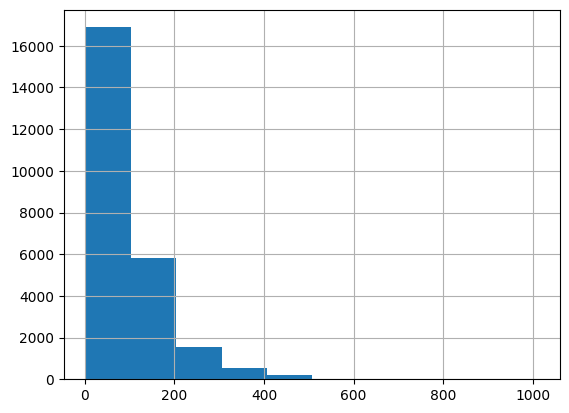

In [138]:
# to decide how many words we want to include in each input-vector for the neural network
lengths = train5_df['lemmas_stopworded'].apply(len)
print(lengths.describe())
lengths.hist()


In [139]:
# mean is 101 words, so using our 100d word-embeddings that would mean an input vector of 101*100 = 10,100 numbers!!
# I am going to look online for word embedding models with fewer dimensions e.g. 50d. 
# If we go with the median of 75 words, then 50*75 = 3750 dimension input, not bad!


In [140]:
#this word model is 50d, trained on tweets (which could be better for understanding movie reviews)
twitter_word_model = api.load("glove-twitter-50")


In [141]:
'hi' in twitter_word_model

True

In [142]:
# now lets try concatenating the first 75 words from each movie review.
def concat_firstn_embeddings(unembedded_word_list, embedding_model=twitter_word_model, embedding_model_dim=50, n=75):
    
    # grab the first 75 words that have an embedding. If they have an embedding then do the embedding, if not then skip
    first_n_words_embedded = []
    num_words_added = 0
    for word in unembedded_word_list:
        # check for embedding and if it exists then add
        if  word in embedding_model and num_words_added<75:
            first_n_words_embedded += [embedding_model[word]]
            num_words_added+=1

    # pad any remaining elements of the vector with 0s
    remaining_elements = n - len(first_n_words_embedded)
    if remaining_elements > 0:
        first_n_words_embedded += [np.zeros(remaining_elements*embedding_model_dim)]
    
    # return as one vector with dimension (1, N) where N=embedding_model_dim*n
    return np.concatenate(first_n_words_embedded).reshape(1,-1)


In [143]:
concat_firstn_embeddings(train5_df['lemmas_stopworded'][0])


array([[ 0.47681 ,  0.68236 ,  0.029395, ...,  0.93245 , -0.98703 ,
        -0.22326 ]], dtype=float32)

In [144]:
concat_firstn_embeddings(['test'])


array([[ 0.85745001,  0.84144002, -0.55326998, ...,  0.        ,
         0.        ,  0.        ]])

In [145]:
# apply to each review in train and test
train5_df['neural_net_3750vector'] = train5_df['lemmas_stopworded'].apply(concat_firstn_embeddings)
test5_df['neural_net_3750vector'] = test5_df['lemmas_stopworded'].apply(concat_firstn_embeddings)


### 5.3.3 Train Neural Net

In [146]:
import tensorflow as tf

In [147]:
# confirm shape of input
train5_df['neural_net_3750vector'][0].shape


(1, 3750)

In [148]:
tf_model = tf.keras.models.Sequential([

tf.keras.layers.Dropout(0.1),

tf.keras.layers.Dense(256, activation='hard_sigmoid'),

tf.keras.layers.Dropout(0.3),

tf.keras.layers.Dense(64, activation='hard_sigmoid'),

tf.keras.layers.Dropout(0.3),

# layer for 1 output probability for binary classification. later, use loss='binary_crossentropy' to train
tf.keras.layers.Dense(1, activation='sigmoid')

])


In [149]:
# The hard sigmoid activation is defined as:

# 0 if if x <= -3
# 1 if x >= 3
# (x/6) + 0.5 if -3 < x < 3
# It's a faster, piecewise linear approximation of the sigmoid activation.

In [150]:
# use untrained network to make a prediction
predictions = tf_model(train5_df['neural_net_3750vector'][0]).numpy()
predictions
# this prediction would correspond to "35% probability that the review was POSITIVE sentiment"


array([[0.61059374]], dtype=float32)

In [151]:
# details for how model training will operate
tf_model.compile(optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy'])


In [152]:
# tensor flow needs the input vectors as tensors (surprise surprise)
def tensorise_1_by_n_vectors(vectors):
    # concatenate a list of vectors with reshape applied to them
    return np.concatenate([vec.reshape((1,1,-1)) for idx,vec in enumerate(vectors)],axis=0)

# this does what we need!
tensor = tensorise_1_by_n_vectors(train5_df['neural_net_3750vector'])
print('tensor shape',tensor.shape)
tensor


tensor shape (25000, 1, 3750)


array([[[ 0.47681001,  0.68235999,  0.029395  , ...,  0.93245   ,
         -0.98703003, -0.22326   ]],

       [[ 0.64328998,  0.30197001,  0.70700997, ...,  0.        ,
          0.        ,  0.        ]],

       [[-0.30520999,  0.29563001,  0.12248   , ..., -0.23303001,
          0.29655999, -0.84798998]],

       ...,

       [[-0.52438998,  0.69869   ,  0.43413001, ...,  0.        ,
          0.        ,  0.        ]],

       [[ 1.46249998, -0.62816   ,  0.19158   , ...,  0.18133999,
         -0.74953997,  1.2299    ]],

       [[ 0.37272   ,  0.20279001,  0.0537    , ...,  0.        ,
          0.        ,  0.        ]]])

In [153]:
# now perform the training
train_X_tensor = tensorise_1_by_n_vectors(train5_df['neural_net_3750vector'])
train_y_tensor = train5_df['target'].to_numpy().reshape(-1,1)

tf_model.fit(train_X_tensor,
             train_y_tensor,
             epochs=10)


Epoch 1/10
782/782 [==============================] - 2s 2ms/step - loss: 0.5615 - accuracy: 0.7126
Epoch 2/10
782/782 [==============================] - 2s 2ms/step - loss: 0.4876 - accuracy: 0.7651
Epoch 3/10
782/782 [==============================] - 2s 2ms/step - loss: 0.4534 - accuracy: 0.7834
Epoch 4/10
782/782 [==============================] - 2s 2ms/step - loss: 0.4078 - accuracy: 0.8042
Epoch 5/10
782/782 [==============================] - 2s 2ms/step - loss: 0.3481 - accuracy: 0.8356
Epoch 6/10
782/782 [==============================] - 2s 2ms/step - loss: 0.2700 - accuracy: 0.8778
Epoch 7/10
782/782 [==============================] - 2s 2ms/step - loss: 0.2060 - accuracy: 0.9113
Epoch 8/10
782/782 [==============================] - 2s 2ms/step - loss: 0.1547 - accuracy: 0.9404
Epoch 9/10
782/782 [==============================] - 2s 2ms/step - loss: 0.1327 - accuracy: 0.9475
Epoch 10/10
782/782 [==============================] - 2s 2ms/step - loss: 0.1109 - accuracy: 0.9596

In [154]:
# now test performance
test_X_tensor = tensorise_1_by_n_vectors(test5_df['neural_net_3750vector'])
test_y_tensor = test5_df['target'].to_numpy().reshape(-1,1)

tf_model.evaluate(test_X_tensor,
                  test_y_tensor,
                  verbose=2)
# overfit a lot!

782/782 - 1s - loss: 0.9914 - accuracy: 0.7287 - 652ms/epoch - 834us/step


[0.991420328617096, 0.7287200093269348]

In [155]:
# details for how model training will operate
tf_model.compile(optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy'])


tf_model.fit(train_X_tensor,
             train_y_tensor,
             epochs=2)
tf_model.evaluate(test_X_tensor,
                  test_y_tensor,
                  verbose=2)

Epoch 1/2
782/782 [==============================] - 2s 2ms/step - loss: 0.0968 - accuracy: 0.9665
Epoch 2/2
782/782 [==============================] - 2s 2ms/step - loss: 0.0859 - accuracy: 0.9698
782/782 - 1s - loss: 1.0876 - accuracy: 0.7286 - 624ms/epoch - 797us/step


[1.0875588655471802, 0.7286400198936462]

In [156]:
def fit_and_test_tfmodel(epochs):
    new_tf_model = tf.keras.models.Sequential([

    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(128, activation='hard_sigmoid'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='hard_sigmoid'),

    tf.keras.layers.Dropout(0.3),

    # layer for 1 output probability for binary classification. later, use loss='binary_crossentropy' to train
    tf.keras.layers.Dense(1, activation='sigmoid')

    ])

    # details for how model training will operate
    new_tf_model.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

    # fit and evaluate
    new_tf_model.fit(train_X_tensor,
                train_y_tensor,
                epochs=2)
    new_tf_model.evaluate(test_X_tensor,
                    test_y_tensor,
                    verbose=2)
    
    # AUC calc
    train_auc = roc_auc_score(train5_df['target'], new_tf_model(train_X_tensor).numpy().reshape(-1))
    test_auc = roc_auc_score(test5_df['target'], new_tf_model(test_X_tensor).numpy().reshape(-1))
    print('Train AUC =',train_auc)
    print('Test AUC =',test_auc)


In [157]:
fit_and_test_tfmodel(epochs=2)


Epoch 1/2
782/782 [==============================] - 2s 2ms/step - loss: 0.5663 - accuracy: 0.7054
Epoch 2/2
782/782 [==============================] - 1s 2ms/step - loss: 0.4853 - accuracy: 0.7671
782/782 - 1s - loss: 0.5240 - accuracy: 0.7377 - 610ms/epoch - 781us/step
Train AUC = 0.8910227008
Test AUC = 0.8198151456


### 5.3.4 Compare Neural Nets

In [158]:
# now we have fit one neural net relatively quickly and easily, lets compare how effective this approach is with different word embeddings, 

In [159]:
# we still have the 100d word model used previously
word_model

In [160]:
# function to run entire model pipeline with specified parameters e.g. different word embedding model
def full_prep_fit_and_test(embedding_model, embedding_model_dim, input_vector_n_words, level1_neuron_count, level2_neuron_count, epochs):
    # copy of dataframes
    train5_dfcopy = train5_df.copy()
    test5_dfcopy = test5_df.copy()

    #produce the input vectors we need for this model
    train5_dfcopy['neural_net_vector'] = train5_dfcopy['lemmas_stopworded'].apply(lambda x: concat_firstn_embeddings(unembedded_word_list=x,
                                                                                                                     embedding_model=embedding_model,
                                                                                                                     embedding_model_dim=embedding_model_dim,
                                                                                                                     n=input_vector_n_words))
    
    test5_dfcopy['neural_net_vector'] = test5_dfcopy['lemmas_stopworded'].apply(lambda x: concat_firstn_embeddings(unembedded_word_list=x,
                                                                                                                     embedding_model=embedding_model,
                                                                                                                     embedding_model_dim=embedding_model_dim,
                                                                                                                     n=input_vector_n_words))
    
    # define neural network structure
    neural_net_model = tf.keras.models.Sequential([
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(level1_neuron_count, activation='hard_sigmoid'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(level2_neuron_count, activation='hard_sigmoid'),
    tf.keras.layers.Dropout(0.3),
    # layer for 1 output probability for binary classification. later, use loss='binary_crossentropy' to train
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    neural_net_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

    # now perform the training
    train_X_tensor = tensorise_1_by_n_vectors(train5_dfcopy['neural_net_vector'])
    train_y_tensor = train5_dfcopy['target'].to_numpy().reshape(-1,1)

    neural_net_model.fit(train_X_tensor, train_y_tensor, epochs=epochs)
    # now test performance
    test_X_tensor = tensorise_1_by_n_vectors(test5_dfcopy['neural_net_vector'])
    test_y_tensor = test5_dfcopy['target'].to_numpy().reshape(-1,1)    

    # AUC calc
    train_auc = roc_auc_score(train5_dfcopy['target'], neural_net_model(train_X_tensor).numpy().reshape(-1))
    test_auc = roc_auc_score(test5_dfcopy['target'], neural_net_model(test_X_tensor).numpy().reshape(-1))
    print('Train AUC =',train_auc, 'Test AUC =', test_auc)
    neural_net_model.evaluate(test_X_tensor, test_y_tensor, verbose=2)



In [161]:
print('Test 1a: Twitter word model (50d) with 75 words as input')
full_prep_fit_and_test(embedding_model=twitter_word_model,
                        embedding_model_dim=50,
                          input_vector_n_words=75,
                            level1_neuron_count=256,
                              level2_neuron_count=64,
                                epochs=2)


Test 1a: Twitter word model (50d) with 75 words as input
Epoch 1/2
782/782 [==============================] - 2s 2ms/step - loss: 0.5602 - accuracy: 0.7094
Epoch 2/2
782/782 [==============================] - 2s 2ms/step - loss: 0.4877 - accuracy: 0.7600
Train AUC = 0.8954829151999999 Test AUC = 0.8232637824000001
782/782 - 1s - loss: 0.5174 - accuracy: 0.7418 - 613ms/epoch - 783us/step


In [162]:
print('Test 1b: For comparison, glove Wiki gigaword model (100d) with 75 words as input')
full_prep_fit_and_test(embedding_model=word_model,
                        embedding_model_dim=100,
                          input_vector_n_words=75,
                            level1_neuron_count=256,
                              level2_neuron_count=64,
                                epochs=2)


Test 1b: For comparison, glove Wiki gigaword model (100d) with 75 words as input
Epoch 1/2
782/782 [==============================] - 3s 3ms/step - loss: 0.5649 - accuracy: 0.7056
Epoch 2/2
782/782 [==============================] - 2s 3ms/step - loss: 0.4680 - accuracy: 0.7785
Train AUC = 0.9218511744 Test AUC = 0.8295436256
782/782 - 1s - loss: 0.5199 - accuracy: 0.7482 - 786ms/epoch - 1ms/step


In [163]:
print('Test 2a: glove Wiki gigaword model (100d) with 150 words as input (and more neurons)')
full_prep_fit_and_test(embedding_model=word_model,
                        embedding_model_dim=100,
                          input_vector_n_words=150,
                            level1_neuron_count=1000,
                              level2_neuron_count=500,
                                epochs=2)


Test 2a: glove Wiki gigaword model (100d) with 150 words as input (and more neurons)
Epoch 1/2
782/782 [==============================] - 13s 16ms/step - loss: 0.5752 - accuracy: 0.7008
Epoch 2/2
782/782 [==============================] - 13s 16ms/step - loss: 0.4667 - accuracy: 0.7776
Train AUC = 0.9284267584000001 Test AUC = 0.8291614688
782/782 - 4s - loss: 0.5552 - accuracy: 0.7262 - 4s/epoch - 6ms/step


In [164]:
print('Test 2b: For comparison, twitter model (50d) with 150 words as input (and more neurons)')
full_prep_fit_and_test(embedding_model=twitter_word_model,
                        embedding_model_dim=50,
                          input_vector_n_words=150,
                            level1_neuron_count=1000,
                              level2_neuron_count=500,
                                epochs=2)


Test 2b: For comparison, twitter model (50d) with 150 words as input (and more neurons)
Epoch 1/2
782/782 [==============================] - 8s 10ms/step - loss: 0.5650 - accuracy: 0.7104
Epoch 2/2
782/782 [==============================] - 8s 10ms/step - loss: 0.4863 - accuracy: 0.7608
Train AUC = 0.9020833184 Test AUC = 0.822188208
782/782 - 3s - loss: 0.5190 - accuracy: 0.7386 - 3s/epoch - 4ms/step


# APPENDIX

In [ ]:
#future ideas:
# features that understand suffixes/prefixes of words
# features that understand n-grams, not just appearance of single words
# use an LLM (e.g. from hugging face) to engineer features
# use word2vec or some form of token vectorisation and engineer feautures from vectors

# Bag of Words (basically same as my binary flagging of word occurences): 
# you turn each review into an m-dimensional vector, where m=number of words in your "vocabulary"
# the ith element of the vector tells you how many occurences of the ith word in your "vocab" appear in that review
#then you simply input these vectors to the ML model... basically like my binary flagging of word occurences

# Bag of bigrams: same idea as bag of words but instead of WORDS your vocabulary is made up of BIGRAMS (pairs of words)

# TF-IDF: term frequency - inverse document frequency
# motivation for this is words like "the" that appear in EVERY document (high document freq) should be penalised

# or word2vec